<div style="display:flex; align-items:center; justify-content:space-between; gap:32px; padding:12px 48px 12px 0;">
  <div style="line-height:1.35;">
    <div style="font-size:48px; font-weight:800; margin-bottom:14px;">Formel 1 Qualifyingvorhersage</div>
    <div style="display:grid; grid-template-columns:120px auto; row-gap:4px; font-size:20px;">
      <strong>Autor:</strong><span>Andrin Sutter</span>
      <strong>Datum:</strong><span>29.05.2026</span>
      <strong>Fach:</strong><span>Machine Learning</span>
      <strong>Notebook:</strong><span>Chronologischer Train/Test-Split</span>
    </div>
  </div>
  <div style="background:#ffffff; border-radius:10px; padding:12px 16px; margin-right:100px; width:400px;">
    <img src="../img/ost_logo.png" alt="OST Logo" style="max-width:250px; height:auto; object-fit:contain; display:block;" />
  </div>
</div>

# **Pipeline**


### **Pakete importieren**

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score, precision_score, recall_score
)
from joblib import dump

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "Daten").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Der Ordner 'Daten' wurde nicht gefunden.")

DATA_DIR = PROJECT_ROOT / "Daten"
HELPER_DIR = PROJECT_ROOT / "ML_Modelle"
if str(HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(HELPER_DIR))

from helper import random_race_split, chronological_race_split

RANDOM_STATE = 42
TEST_SIZE = 0.2


### **Daten laden**

Es wird der Datensatz geladen, welcher im `Preprocessing.ipynb` erstellt wurde. Der Datensatz enthält Trainings-, Qualifying- und Wetterdaten aus den Formel-1-Saisons 2018 bis 2026.

In [2]:
df = pd.read_csv(DATA_DIR / "ML_Data_Encoded.csv", sep=";", encoding="utf-8")

print(df.shape)

df.head()

(2923, 111)


,season,round,fp1_besttime,fp2_besttime,fp3_besttime,q1_besttime,q2_besttime,q3_besttime,startposition,fp1_mean_airtemp,...,team_name_Mercedes,team_name_Racing Bulls,team_name_Red Bull Racing,team_name_Williams,qualified_for_q2_True,qualified_for_q3_True,fp1_has_rain_True,fp2_has_rain_True,fp3_has_rain_True,qualifying_has_rain_True
0,2018,1,84.026,83.931,94.225,82.824,82.051,81.164,1,26.781,...,True,False,False,False,True,True,False,False,True,False
1,2018,1,84.875,84.214,88.499,83.096,82.507,81.828,2,26.781,...,False,False,False,False,True,True,False,False,True,False
2,2018,1,84.995,84.460,86.067,83.348,81.944,81.838,3,26.781,...,False,False,False,False,True,True,False,False,True,False
3,2018,1,84.771,84.058,91.680,83.483,82.416,81.879,4,26.781,...,False,False,True,False,True,True,False,False,True,False
4,2018,1,85.063,84.721,94.043,83.494,82.897,82.152,5,26.781,...,False,False,True,False,True,True,False,False,True,False


### **Targets**

Es wird für jeden Qualifying-Abschnitt ein DataFrame erstellt mit den relevanten Daten. Für das Q2 und Q3 werden die bereits ausgeschiedenen Fahrer entfernt.

In [3]:
df_q1 = df.copy()
df_q2 = df[df['qualified_for_q2_True'] == True]
df_q3 = df[df['qualified_for_q3_True'] == True]

Jeder Qualifying-Abschnitt erhält ein eigenes Target, welches die beste Zeit ist.

In [4]:
y_q1 = df_q1['q1_besttime']
y_q2 = df_q2['q2_besttime']
y_q3 = df_q3['q3_besttime']
print(y_q1.shape, y_q2.shape, y_q3.shape)

(2923,) (2148,) (1424,)


### **Features**

Pro Qualifying-Abschnitt wird ein Feature-DataFrame erstellt.

In [5]:
X_q1 = df_q1.drop(columns=['q1_besttime', 'q2_besttime', 'q3_besttime', 'startposition', 'qualified_for_q2_True', 'qualified_for_q3_True'])
X_q2 = df_q2.drop(columns=['q2_besttime', 'q3_besttime', 'startposition', 'qualified_for_q3_True'])
X_q3 = df_q3.drop(columns=['q3_besttime', 'startposition'])

print(X_q1.shape, X_q2.shape, X_q3.shape)

(2923, 105) (2148, 107) (1424, 109)


### **Train/Test-Split**

Zur objektiven Bewertung der Modelle werden die Daten in Trainings- und Testdaten aufgeteilt. Die Trainingsdaten werden zum Lernen der Modellparameter verwendet, während die Testdaten ausschliesslich zur abschliessenden Leistungsbewertung dienen. Dadurch kann abgeschätzt werden, wie gut das Modell auf unbekannte Rennwochenenden generalisiert.

Mit der Funktion `chronological_race_split()` aus `helper.py` wird der Train/Test-Split gemacht. Dabei werden Einträge zu einem Rennen zusammen behalten. Der Split erfolgt chronologisch.

In [6]:
X_train_q1, X_test_q1, y_train_q1, y_test_q1, train_races_q1, test_races_q1 = chronological_race_split(X_q1, y_q1, test_size=TEST_SIZE)
X_train_q2, X_test_q2, y_train_q2, y_test_q2, train_races_q2, test_races_q2 = chronological_race_split(X_q2, y_q2, test_size=TEST_SIZE)
X_train_q3, X_test_q3, y_train_q3, y_test_q3, train_races_q3, test_races_q3 = chronological_race_split(X_q3, y_q3, test_size=TEST_SIZE)

datasets = {
    "Q1": {
        "X_train": X_train_q1,
        "X_test": X_test_q1,
        "y_train": y_train_q1,
        "y_test": y_test_q1,
        "train_races": train_races_q1,
        "test_races": test_races_q1,
    },
    "Q2": {
        "X_train": X_train_q2,
        "X_test": X_test_q2,
        "y_train": y_train_q2,
        "y_test": y_test_q2,
        "train_races": train_races_q2,
        "test_races": test_races_q2,
    },
    "Q3": {
        "X_train": X_train_q3,
        "X_test": X_test_q3,
        "y_train": y_train_q3,
        "y_test": y_test_q3,
        "train_races": train_races_q3,
        "test_races": test_races_q3,
    },
}


### **Modelle definieren**

#### Modell 1: Lineare Regression
Die lineare Regression dient als einfaches Baseline-Modell. Sie beschreibt den Zusammenhang zwischen den Eingangsgrössen und der Zielvariable durch eine lineare Funktion.

#### Modell 2: Ridge Regression
Die Ridge Regression erweitert die lineare Regression um eine L2-Regularisierung. Dadurch werden grosse Regressionskoeffizienten bestraft und Overfitting reduziert.

#### Modell 3: Random Forest
Der Random Forest gehört zu den Ensemble-Methoden und kombiniert eine Vielzahl von Entscheidungsbäumen. Durch die Mittelung vieler Bäume können nichtlineare Zusammenhänge modelliert und die Varianz einzelner Entscheidungsbäume reduziert werden.

#### Modell 4: Gradient Boosting
Gradient Boosting erstellt mehrere schwache Lerner sequenziell. Jeder neue Baum versucht die Fehler der vorherigen Modelle zu korrigieren. Dadurch können komplexe Zusammenhänge sehr präzise modelliert werden.

In [7]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ])
}

Die Funktion `calc_metrics()` berechnet die wichtigsten Regressionsmetriken zur Bewertung eines Modells. Dazu werden die tatsächlichen Zielwerte `y_true` mit den vorhergesagten Werten `y_pred` verglichen.

Folgende Kennzahlen werden bestimmt:

- RMSE (Root Mean Squared Error): Bestraft grosse Fehler stärker und gibt die durchschnittliche Vorhersageabweichung an.
- MAE (Mean Absolute Error): Mittlere absolute Vorhersageabweichung.
- R² (Bestimmtheitsmass): Beschreibt, welcher Anteil der Varianz der Zielvariable durch das Modell erklärt werden kann.

In [8]:
def calc_metrics(y_true, y_pred):
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }

Die Funktion `cross-validate_model()` führt eine k-fache Kreuzvalidierung durch. Dabei werden die Trainingsdaten mehrfach in Trainings- und Validierungsmengen aufgeteilt.

Für jeden Fold wird das Modell neu trainiert und bewertet. Anschliessend werden Mittelwert und Standardabweichung der CV-Metriken berechnet.

Dadurch entsteht eine robustere Schätzung der Modellleistung als bei einem einzelnen Train-Test-Split. Gleichzeitig kann die Streuung der Ergebnisse als Mass für die Stabilität des Modells interpretiert werden.

Da mehrere Fahrer zum selben Rennwochenende gehören, wird eine gruppierte Kreuzvalidierung verwendet. Dadurch befinden sich Daten eines Rennens niemals gleichzeitig im Trainings- und Validierungsdatensatz. Dies verhindert Datenlecks und führt zu einer realistischeren Leistungsbewertung.

In [ ]:
def cross_validate_model(model, X_train, y_train,  cv_splits):
    cv = GroupKFold(n_splits=cv_splits)

    groups = X_train[["season", "round"]].astype(str).agg("_".join, axis=1)

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        groups=groups,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    result = {
        "CV_RMSE_mean": -cv_results["test_rmse"].mean(),
        "CV_RMSE_std": cv_results["test_rmse"].std(),
        "CV_MAE_mean": -cv_results["test_mae"].mean(),
        "CV_MAE_std": cv_results["test_mae"].std(),
        "CV_R2_mean": cv_results["test_r2"].mean(),
        "CV_R2_std": cv_results["test_r2"].std(),
    }

    return result

Mit der Funktion `evaluate_model()` wird der gesamten Bewertungsprozess eines Modells zusammengefasst.

Dabei werden folgende Schritte durchgeführt:

- Kreuzvalidierung
- Training des Modells auf den Trainingsdaten
- Berechnung der Vorhersagen auf den Testdaten
- Berechnung der Regressionsmetriken
- Zusammenfassung aller Ergebnisse in einer übersichtlichen Struktur

In [10]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, cv_splits=5):
    model_cv = clone(model)

    cv_metrics = cross_validate_model(
        model_cv,
        X_train,
        y_train,
        cv_splits=cv_splits
    )

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred = fitted_model.predict(X_test)
    holdout_metrics = calc_metrics(y_test, y_pred)

    result = {
        "Model": model_name,
        **cv_metrics,
        "Test_RMSE": holdout_metrics["rmse"],
        "Test_MAE": holdout_metrics["mae"],
        "Test_R2": holdout_metrics["r2"]
    }

    return result, fitted_model

# **No Free Lunch**

Im folgenden Codeblock wird für jeden Qualifying-Abschnitt (Q1, Q2, Q3) alle Modelle ausgewertet mit den vorherigen Funktion.

In [11]:
model_results = []
fitted_models = {model_name: {} for model_name in models}

for model_name, model in models.items():
    for quali_phase, data in datasets.items():
        result, fitted_model = evaluate_model(
            model=model,
            model_name=model_name,
            X_train=data["X_train"],
            y_train=data["y_train"],
            X_test=data["X_test"],
            y_test=data["y_test"],
            cv_splits=5
        )

        result["Qualifying_Phase"] = quali_phase
        model_results.append(result)
        fitted_models[model_name][quali_phase] = fitted_model

res_df = (
    pd.DataFrame(model_results)
    .sort_values(["Qualifying_Phase", "CV_RMSE_mean"], ascending=[True, True])
    .reset_index(drop=True)
)

res_df.round(3)


,Model,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,Test_RMSE,Test_MAE,Test_R2,Qualifying_Phase
0,Random Forest,3.705,0.778,1.839,0.430,0.889,0.060,4.199,1.585,0.883,Q1
1,Gradient Boosting,3.765,0.676,1.928,0.393,0.885,0.057,3.807,1.512,0.904,Q1
2,Ridge Regression,4.333,0.908,2.899,0.623,0.859,0.046,4.165,2.261,0.885,Q1
3,Linear Regression,4.360,0.905,2.935,0.625,0.857,0.045,4.176,2.291,0.885,Q1
4,Gradient Boosting,2.353,1.273,1.102,0.637,0.951,0.036,1.136,0.575,0.991,Q2
5,Random Forest,2.513,1.247,1.097,0.618,0.946,0.037,1.063,0.492,0.992,Q2
6,Ridge Regression,2.727,0.580,1.756,0.379,0.942,0.014,1.767,1.332,0.978,Q2
7,Linear Regression,2.763,0.555,1.784,0.378,0.940,0.014,1.764,1.330,0.978,Q2
8,Ridge Regression,3.104,0.660,1.880,0.135,0.930,0.016,2.043,1.560,0.970,Q3
9,Linear Regression,3.178,0.753,1.968,0.185,0.927,0.014,2.048,1.587,0.970,Q3


In der Tabelle sind Ergebnisse der Kreuzvalidierung und der Regressionsmetriken abgebildet. Die Tabelle wurde nach `CV_RMSE_mean` sortiert.

# **Validierung**

### **Ergebnisse Visualisieren**

Die Daten aus der letzen Tabelle (Ergebnisse der Kreuzvalidierung und der Regressionsmetriken) werden mit dem folgenden Codeblock in Säulendiagrammen visualisiert um die Auswertung einfacher zumachen.

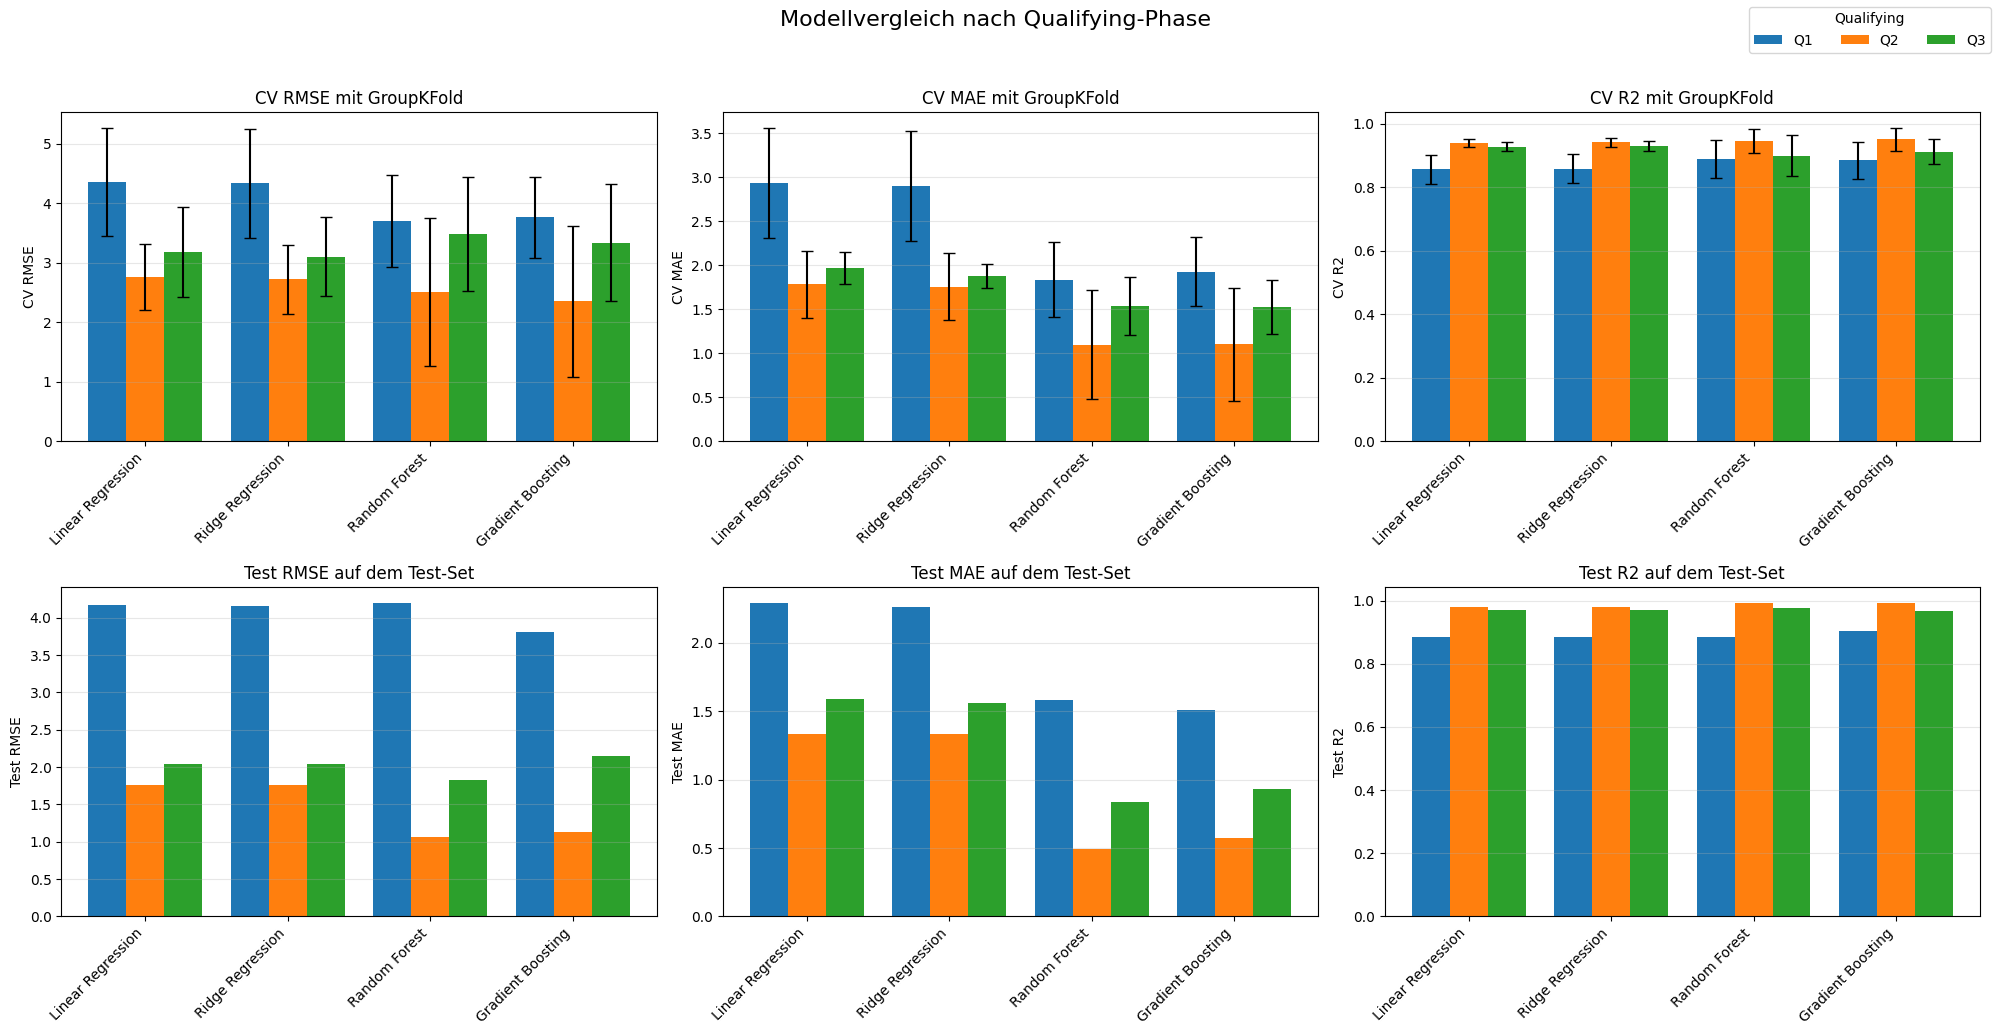

In [35]:
visualization_df = res_df.copy()
model_order = list(models.keys())
phase_order = list(datasets.keys())

visualization_df["Model"] = pd.Categorical(
    visualization_df["Model"],
    categories=model_order,
    ordered=True
)
visualization_df["Qualifying_Phase"] = pd.Categorical(
    visualization_df["Qualifying_Phase"],
    categories=phase_order,
    ordered=True
)
visualization_df = visualization_df.sort_values(["Model", "Qualifying_Phase"])


def plot_grouped_metric(ax, metric, ylabel, title, yerr_col=None):
    x = np.arange(len(model_order))
    width = 0.8 / len(phase_order)

    for i, quali_phase in enumerate(phase_order):
        phase_results = (
            visualization_df[visualization_df["Qualifying_Phase"] == quali_phase]
            .set_index("Model")
            .reindex(model_order)
        )
        offset = (i - (len(phase_order) - 1) / 2) * width
        yerr = phase_results[yerr_col] if yerr_col else None

        ax.bar(
            x + offset,
            phase_results[metric],
            width=width,
            yerr=yerr,
            capsize=4 if yerr_col else 0,
            label=quali_phase
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)


metrics_to_plot = [
    ("CV_RMSE_mean", "CV_RMSE_std", "CV RMSE", "CV RMSE mit GroupKFold"),
    ("CV_MAE_mean", "CV_MAE_std", "CV MAE", "CV MAE mit GroupKFold"),
    ("CV_R2_mean", "CV_R2_std", "CV R2", "CV R2 mit GroupKFold"),
    ("Test_RMSE", None, "Test RMSE", "Test RMSE auf dem Test-Set"),
    ("Test_MAE", None, "Test MAE", "Test MAE auf dem Test-Set"),
    ("Test_R2", None, "Test R2", "Test R2 auf dem Test-Set"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for ax, (metric, yerr_col, ylabel, title) in zip(axes.ravel(), metrics_to_plot):
    plot_grouped_metric(
        ax,
        metric=metric,
        yerr_col=yerr_col,
        ylabel=ylabel,
        title=title
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Qualifying", loc="upper right", ncol=len(phase_order))
fig.suptitle("Modellvergleich nach Qualifying-Phase", y=1.03, fontsize=16)
plt.tight_layout()
plt.show()


Der Modellvergleich zeigt deutliche Unterschiede zwischen den drei Vorhersageaufgaben (Q1-Zeit, Q2-Zeit, Q3-Zeit). 

Die Modelle für die Q2-Zeiten konnten sowohl in der Kreuzvalidierung als auch in den Test-Metriken am besten abschliesse. Am zweit besten sind die Q3 Modelle.

Die Random Forest Modelle und die Gradient-Boosting-Modelle haben in der Kreuzvalidierung und in den Test-Metriken die besseren Ergebnisse als die beiden Linearen Modelle.

Die Test-Metriken stimmen in den meisten Fällen mit der Kreuzvalidierung überein.

### **Q2/Q3-Klassifikation aus vorhergesagten Zeiten**

In diesem Abschnitt wird anhand der vorhergesagten Qualifying-Zeiten ermittelt, ob ein Fahrer Q2 oder Q3 erreicht.

Für die Vorhersage der Q2-Teilnahme wird das jeweilige Q1-Zeitmodell verwendet, da die Q1-Rangliste entscheidet, wer Q2 erreicht. Für die Vorhersage der Q3-Teilnahme wird entsprechend das jeweilige Q2-Zeitmodell verwendet, da die Q2-Rangliste entscheidet, wer Q3 erreicht.

Hierzu werden die vorhergesagten Zeiten innerhalb jedes Rennwochenendes aufsteigend sortiert. Anschliessend werden die Fahrer anhand ihrer prognostizierten Rangposition klassifiziert. Für Q2 werden die schnellsten 15 Fahrer (bzw. 16 Fahrer bei 22 Startern) als qualifiziert betrachtet. Für Q3 werden die schnellsten 10 Fahrer als qualifiziert eingestuft. Diese Klassifikation wird anschliessend mit den tatsächlichen Qualifikationsergebnissen verglichen.

In [13]:
def get_actual_labels_for_test_races(source_df, test_features, actual_col):
    test_keys = set(map(tuple, test_features[["season", "round"]].drop_duplicates().to_numpy()))
    source_reset = source_df.reset_index(drop=True)
    race_keys = list(map(tuple, source_reset[["season", "round"]].to_numpy()))
    test_mask = pd.Series([key in test_keys for key in race_keys])

    return source_reset.loc[test_mask, actual_col].reset_index(drop=True)


def q2_cutoff(driver_count):
    if driver_count >= 22:
        return 16
    return min(15, driver_count)


def q3_cutoff(driver_count):
    return min(10, driver_count)


def predict_qualification_by_rank(model, X_test, source_df, actual_col, cutoff_function):
    evaluation_df = X_test[["season", "round"]].copy().reset_index(drop=True)
    evaluation_df["actual_reached"] = get_actual_labels_for_test_races(
        source_df=source_df,
        test_features=X_test,
        actual_col=actual_col,
    ).astype(bool)
    evaluation_df["predicted_time"] = model.predict(X_test)
    evaluation_df["driver_count"] = evaluation_df.groupby(["season", "round"])["predicted_time"].transform("size")
    evaluation_df["cutoff"] = evaluation_df["driver_count"].map(cutoff_function)
    evaluation_df["predicted_rank"] = evaluation_df.groupby(["season", "round"])["predicted_time"].rank(
        method="first",
        ascending=True,
    )
    evaluation_df["predicted_reached"] = evaluation_df["predicted_rank"] <= evaluation_df["cutoff"]

    return evaluation_df


def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[False, True]).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1_Score": f1_score(y_true, y_pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

In [14]:
classification_tasks = {
    "Q1": {
        "X_test": X_test_q1,
        "source_df": df_q1,
        "actual_col": "qualified_for_q2_True",
        "cutoff_function": q2_cutoff,
    },
    "Q2": {
        "X_test": X_test_q2,
        "source_df": df_q2,
        "actual_col": "qualified_for_q3_True",
        "cutoff_function": q3_cutoff,
    },
}

classification_results = []
classification_tables = {}

for model_name in models:
    for quali_phase, task in classification_tasks.items():
        evaluation = predict_qualification_by_rank(
            model=fitted_models[model_name][quali_phase],
            X_test=task["X_test"],
            source_df=task["source_df"],
            actual_col=task["actual_col"],
            cutoff_function=task["cutoff_function"],
        )

        classification_tables[(model_name, quali_phase)] = evaluation
        classification_results.append({
            "Model": model_name,
            "Qualifying_Phase": quali_phase,
            **classification_metrics(
                evaluation["actual_reached"],
                evaluation["predicted_reached"],
            ),
        })

classification_results_df = (pd.DataFrame(classification_results).sort_values(["Qualifying_Phase", "Accuracy"], ascending=[True, False])).reset_index(drop=True)

In [15]:
classification_results_df[[
    "Model",
    "Qualifying_Phase",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "TN",
    "FP",
    "FN",
    "TP",
]].round(3)


,Model,Qualifying_Phase,Accuracy,Precision,Recall,F1_Score,TN,FP,FN,TP
0,Gradient Boosting,Q1,0.788,0.850,0.865,0.857,92,68,60,384
1,Random Forest,Q1,0.758,0.830,0.845,0.837,83,77,69,375
2,Linear Regression,Q1,0.732,0.812,0.827,0.819,75,85,77,367
3,Ridge Regression,Q1,0.732,0.812,0.827,0.819,75,85,77,367
4,Random Forest,Q2,0.764,0.813,0.833,0.823,95,56,49,244
5,Linear Regression,Q2,0.714,0.777,0.795,0.786,84,67,60,233
6,Ridge Regression,Q2,0.709,0.773,0.792,0.782,83,68,61,232
7,Gradient Boosting,Q2,0.709,0.773,0.792,0.782,83,68,61,232


Die Ensemble-Methoden erzielten insgesamt die beste Klassifikationsleistung. Für die Vorhersage des Erreichens von Q2 erreichte das Gradient-Boosting-Modell mit einer Accuracy von 78.8 % und einem F1-Score von 0.857 die besten Ergebnisse. 

Für die Vorhersage des Erreichens von Q3 erwies sich dagegen der Random Forest mit einer Accuracy von 76.4 % und einem F1-Score von 0.823 als leistungsstärkster Lerner. 

Die linearen Modelle erzielten durchgehend geringere Werte, was darauf hindeutet, dass die Zusammenhänge zwischen Trainingsdaten, Wetterbedingungen und Qualifikationsergebnis nicht rein linear sind.

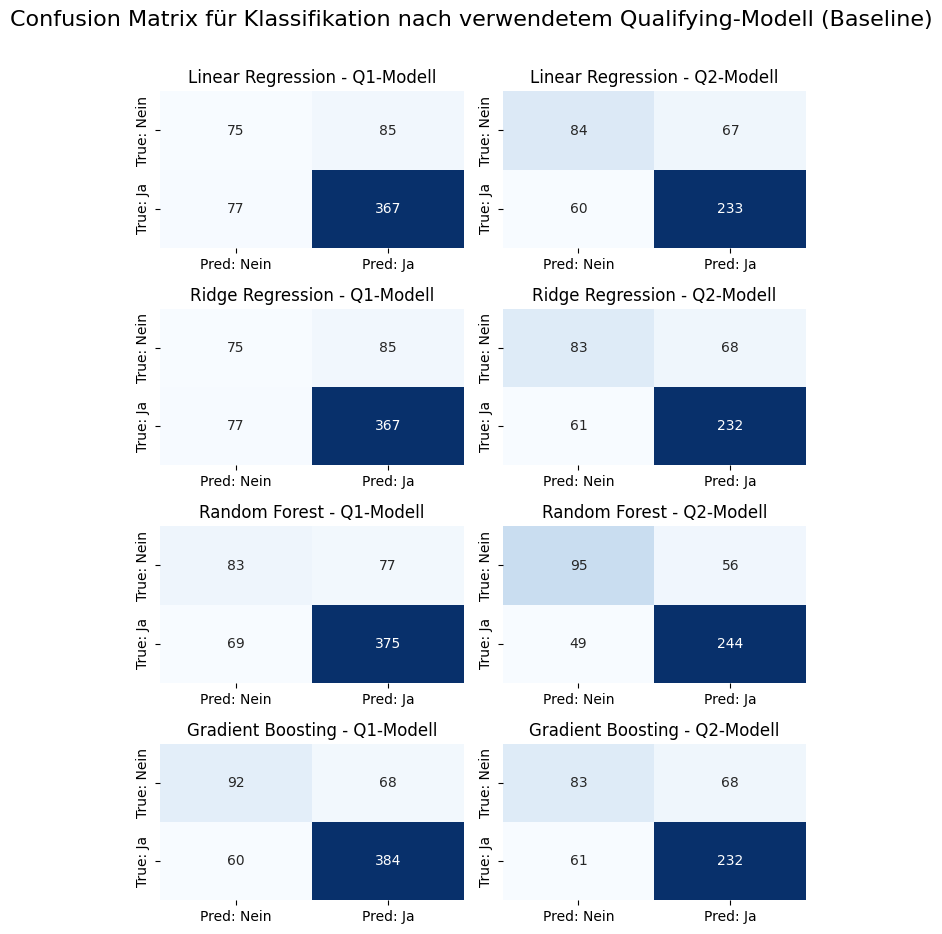

In [16]:
fig, axes = plt.subplots(len(models), 2, figsize=(7, 2.3 * len(models)))

for row_idx, model_name in enumerate(models):
    for col_idx, quali_phase in enumerate(["Q1", "Q2"]):
        ax = axes[row_idx, col_idx]
        row = classification_results_df[
            (classification_results_df["Model"] == model_name)
            & (classification_results_df["Qualifying_Phase"] == quali_phase)
        ].iloc[0]
        matrix = np.array([
            [row["TN"], row["FP"]],
            [row["FN"], row["TP"]],
        ])

        sns.heatmap(
            matrix,
            annot=True,
            fmt=".0f",
            cmap="Blues",
            cbar=False,
            xticklabels=["Pred: Nein", "Pred: Ja"],
            yticklabels=["True: Nein", "True: Ja"],
            ax=ax,
        )
        ax.set_title(f"{model_name} - {quali_phase}-Modell")
        ax.set_xlabel("")
        ax.set_ylabel("")

fig.suptitle("Confusion Matrix für Klassifikation nach verwendetem Qualifying-Modell (Baseline)", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()


Die Konfusionsmatrizen zeigen, dass alle Modelle deutlich mehr True Positives und True Negatives als Fehlklassifikationen erzeugen.

Insgesamt bestätigen die Klassifikationsergebnisse die Erkenntnisse aus der Regressionsanalyse. Die vorhergesagten Qualifying-Zeiten enthalten genügend Information, um mit hoher Genauigkeit vorherzusagen, welche Fahrer den Einzug in Q2 beziehungsweise Q3 schaffen werden.

### **Hyperparameter-Tuning**

Nachdem die Baseline-Modelle trainiert und bewertet wurden, erfolgt im nächsten Schritt die Optimierung der Hyperparameter. Im Gegensatz zu den Modellparametern, welche während des Trainings automatisch aus den Daten gelernt werden, müssen Hyperparameter vor dem Training festgelegt werden. Beispiele hierfür sind die Regularisierungsstärke α bei der Ridge Regression, die maximale Baumtiefe bei Random Forest oder die Lernrate beim Gradient Boosting.

Ziel des Hyperparameter-Tunings ist es, die Generalisierungsfähigkeit der Modelle zu verbessern und dadurch eine höhere Vorhersagegenauigkeit auf bislang unbekannten Rennwochenenden zu erreichen. Die optimale Kombination der Hyperparameter wurde mittels Grid Search in Verbindung mit einer GroupKFold-Kreuzvalidierung bestimmt. Als Auswahlkriterium diente der mittlere RMSE (Root Mean Squared Error) der Kreuzvalidierung. Die Parameterkombination mit dem kleinsten mittleren RMSE wurde als optimales Modell übernommen.

In [17]:
param_grids = {
    "Ridge Regression": {
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    },

    "Random Forest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [5, 10, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5],
        "model__subsample": [0.8, 1.0]
    }
}


def tune_models(models, param_grids, datasets, cv_splits=5):
    cv = GroupKFold(n_splits=cv_splits)
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    tuned_results = []
    grid_searches = {model_name: {} for model_name in param_grids}
    best_models = {model_name: {} for model_name in param_grids}

    for model_name, param_grid in param_grids.items():
        for quali_phase, data in datasets.items():
            print(f"Tuning: {model_name} ({quali_phase})")

            groups_train = data["X_train"][["season", "round"]].astype(str).agg("_".join, axis=1)

            grid_search = GridSearchCV(
                estimator=clone(models[model_name]),
                param_grid=param_grid,
                scoring=scoring,
                refit="rmse",
                cv=cv,
                n_jobs=-1,
                return_train_score=True
            )

            grid_search.fit(
                data["X_train"],
                data["y_train"],
                groups=groups_train
            )

            best_idx = grid_search.best_index_
            y_pred = grid_search.best_estimator_.predict(data["X_test"])
            holdout_metrics = calc_metrics(data["y_test"], y_pred)

            tuned_results.append({
                "Model": model_name,
                "Model_Version": "Tuned",
                "Qualifying_Phase": quali_phase,
                "CV_RMSE_mean": -grid_search.cv_results_["mean_test_rmse"][best_idx],
                "CV_RMSE_std": grid_search.cv_results_["std_test_rmse"][best_idx],
                "CV_MAE_mean": -grid_search.cv_results_["mean_test_mae"][best_idx],
                "CV_MAE_std": grid_search.cv_results_["std_test_mae"][best_idx],
                "CV_R2_mean": grid_search.cv_results_["mean_test_r2"][best_idx],
                "CV_R2_std": grid_search.cv_results_["std_test_r2"][best_idx],
                "Best_CV_RMSE": -grid_search.best_score_,
                "Test_RMSE": holdout_metrics["rmse"],
                "Test_MAE": holdout_metrics["mae"],
                "Test_R2": holdout_metrics["r2"],
                "Best_Params": grid_search.best_params_
            })

            grid_searches[model_name][quali_phase] = grid_search
            best_models[model_name][quali_phase] = grid_search.best_estimator_

    tuned_results_df = (
        pd.DataFrame(tuned_results)
        .sort_values("CV_RMSE_mean", ascending=True)
        .reset_index(drop=True)
    )

    return tuned_results_df, best_models, grid_searches


**Modelle tunen**

In [18]:
tuned_results_df, best_models, grid_searches = tune_models(
    models=models,
    param_grids=param_grids,
    datasets=datasets,
    cv_splits=5
)

Tuning: Ridge Regression (Q1)
Tuning: Ridge Regression (Q2)
Tuning: Ridge Regression (Q3)
Tuning: Random Forest (Q1)
Tuning: Random Forest (Q2)
Tuning: Random Forest (Q3)
Tuning: Gradient Boosting (Q1)
Tuning: Gradient Boosting (Q2)
Tuning: Gradient Boosting (Q3)


In [19]:
tuned_results_df.round(3)

,Model,Model_Version,Qualifying_Phase,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,Best_CV_RMSE,Test_RMSE,Test_MAE,Test_R2,Best_Params
0,Gradient Boosting,Tuned,Q2,2.249,1.161,1.046,0.561,0.958,0.029,2.249,1.126,0.591,0.991,"{'model__learning_rate': 0.05, 'model__max_dep..."
1,Random Forest,Tuned,Q2,2.472,1.279,1.078,0.632,0.947,0.038,2.472,0.836,0.466,0.995,"{'model__max_depth': 10, 'model__min_samples_l..."
2,Ridge Regression,Tuned,Q2,2.660,0.657,1.686,0.365,0.944,0.017,2.660,1.821,1.343,0.977,{'model__alpha': 10}
3,Ridge Regression,Tuned,Q3,3.071,0.588,1.852,0.102,0.928,0.028,3.071,2.137,1.560,0.967,{'model__alpha': 10}
4,Gradient Boosting,Tuned,Q1,3.164,0.713,1.564,0.389,0.916,0.049,3.164,4.104,1.491,0.889,"{'model__learning_rate': 0.05, 'model__max_dep..."
5,Gradient Boosting,Tuned,Q3,3.329,1.024,1.526,0.333,0.913,0.041,3.329,2.093,0.827,0.969,"{'model__learning_rate': 0.05, 'model__max_dep..."
6,Random Forest,Tuned,Q3,3.412,1.015,1.512,0.359,0.903,0.066,3.412,1.985,0.904,0.972,"{'model__max_depth': 10, 'model__min_samples_l..."
7,Random Forest,Tuned,Q1,3.596,0.768,1.793,0.403,0.893,0.059,3.596,4.181,1.597,0.884,"{'model__max_depth': 10, 'model__min_samples_l..."
8,Ridge Regression,Tuned,Q1,4.009,1.136,2.622,0.529,0.878,0.053,4.009,4.198,1.914,0.883,{'model__alpha': 100}


In [20]:
baseline_results_df = res_df.copy()
baseline_results_df["Model_Version"] = "Baseline"
baseline_results_df["Best_Params"] = None
baseline_results_df["Base_Models"] = None

tuned_results_display_df = tuned_results_df.copy()
tuned_results_display_df["Base_Models"] = None

all_results_df = (
    pd.concat(
        [baseline_results_df, tuned_results_display_df],
        ignore_index=True,
        sort=False,
    )
    .sort_values(["Qualifying_Phase", "CV_RMSE_mean", "Model_Version"], ascending=[True, True, True])
    .reset_index(drop=True)
)

all_results_df[[
    "Model",
    "Model_Version",
    "Qualifying_Phase",
    "CV_RMSE_mean",
    "CV_RMSE_std",
    "CV_MAE_mean",
    "CV_MAE_std",
    "CV_R2_mean",
    "CV_R2_std",
    "Test_RMSE",
    "Test_MAE",
    "Test_R2",
    "Best_Params",
    "Base_Models",
]].round(3)

,Model,Model_Version,Qualifying_Phase,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,Test_RMSE,Test_MAE,Test_R2,Best_Params,Base_Models
0,Gradient Boosting,Tuned,Q1,3.164,0.713,1.564,0.389,0.916,0.049,4.104,1.491,0.889,"{'model__learning_rate': 0.05, 'model__max_dep...",None
1,Random Forest,Tuned,Q1,3.596,0.768,1.793,0.403,0.893,0.059,4.181,1.597,0.884,"{'model__max_depth': 10, 'model__min_samples_l...",None
2,Random Forest,Baseline,Q1,3.705,0.778,1.839,0.430,0.889,0.060,4.199,1.585,0.883,None,None
3,Gradient Boosting,Baseline,Q1,3.765,0.676,1.928,0.393,0.885,0.057,3.807,1.512,0.904,None,None
4,Ridge Regression,Tuned,Q1,4.009,1.136,2.622,0.529,0.878,0.053,4.198,1.914,0.883,{'model__alpha': 100},None
5,Ridge Regression,Baseline,Q1,4.333,0.908,2.899,0.623,0.859,0.046,4.165,2.261,0.885,None,None
6,Linear Regression,Baseline,Q1,4.360,0.905,2.935,0.625,0.857,0.045,4.176,2.291,0.885,None,None
7,Gradient Boosting,Tuned,Q2,2.249,1.161,1.046,0.561,0.958,0.029,1.126,0.591,0.991,"{'model__learning_rate': 0.05, 'model__max_dep...",None
8,Gradient Boosting,Baseline,Q2,2.353,1.273,1.102,0.637,0.951,0.036,1.136,0.575,0.991,None,None
9,Random Forest,Tuned,Q2,2.472,1.279,1.078,0.632,0.947,0.038,0.836,0.466,0.995,"{'model__max_depth': 10, 'model__min_samples_l...",None


### **Visualisierung der Ergebnisse der Basismodelle und der getunten Modelle**

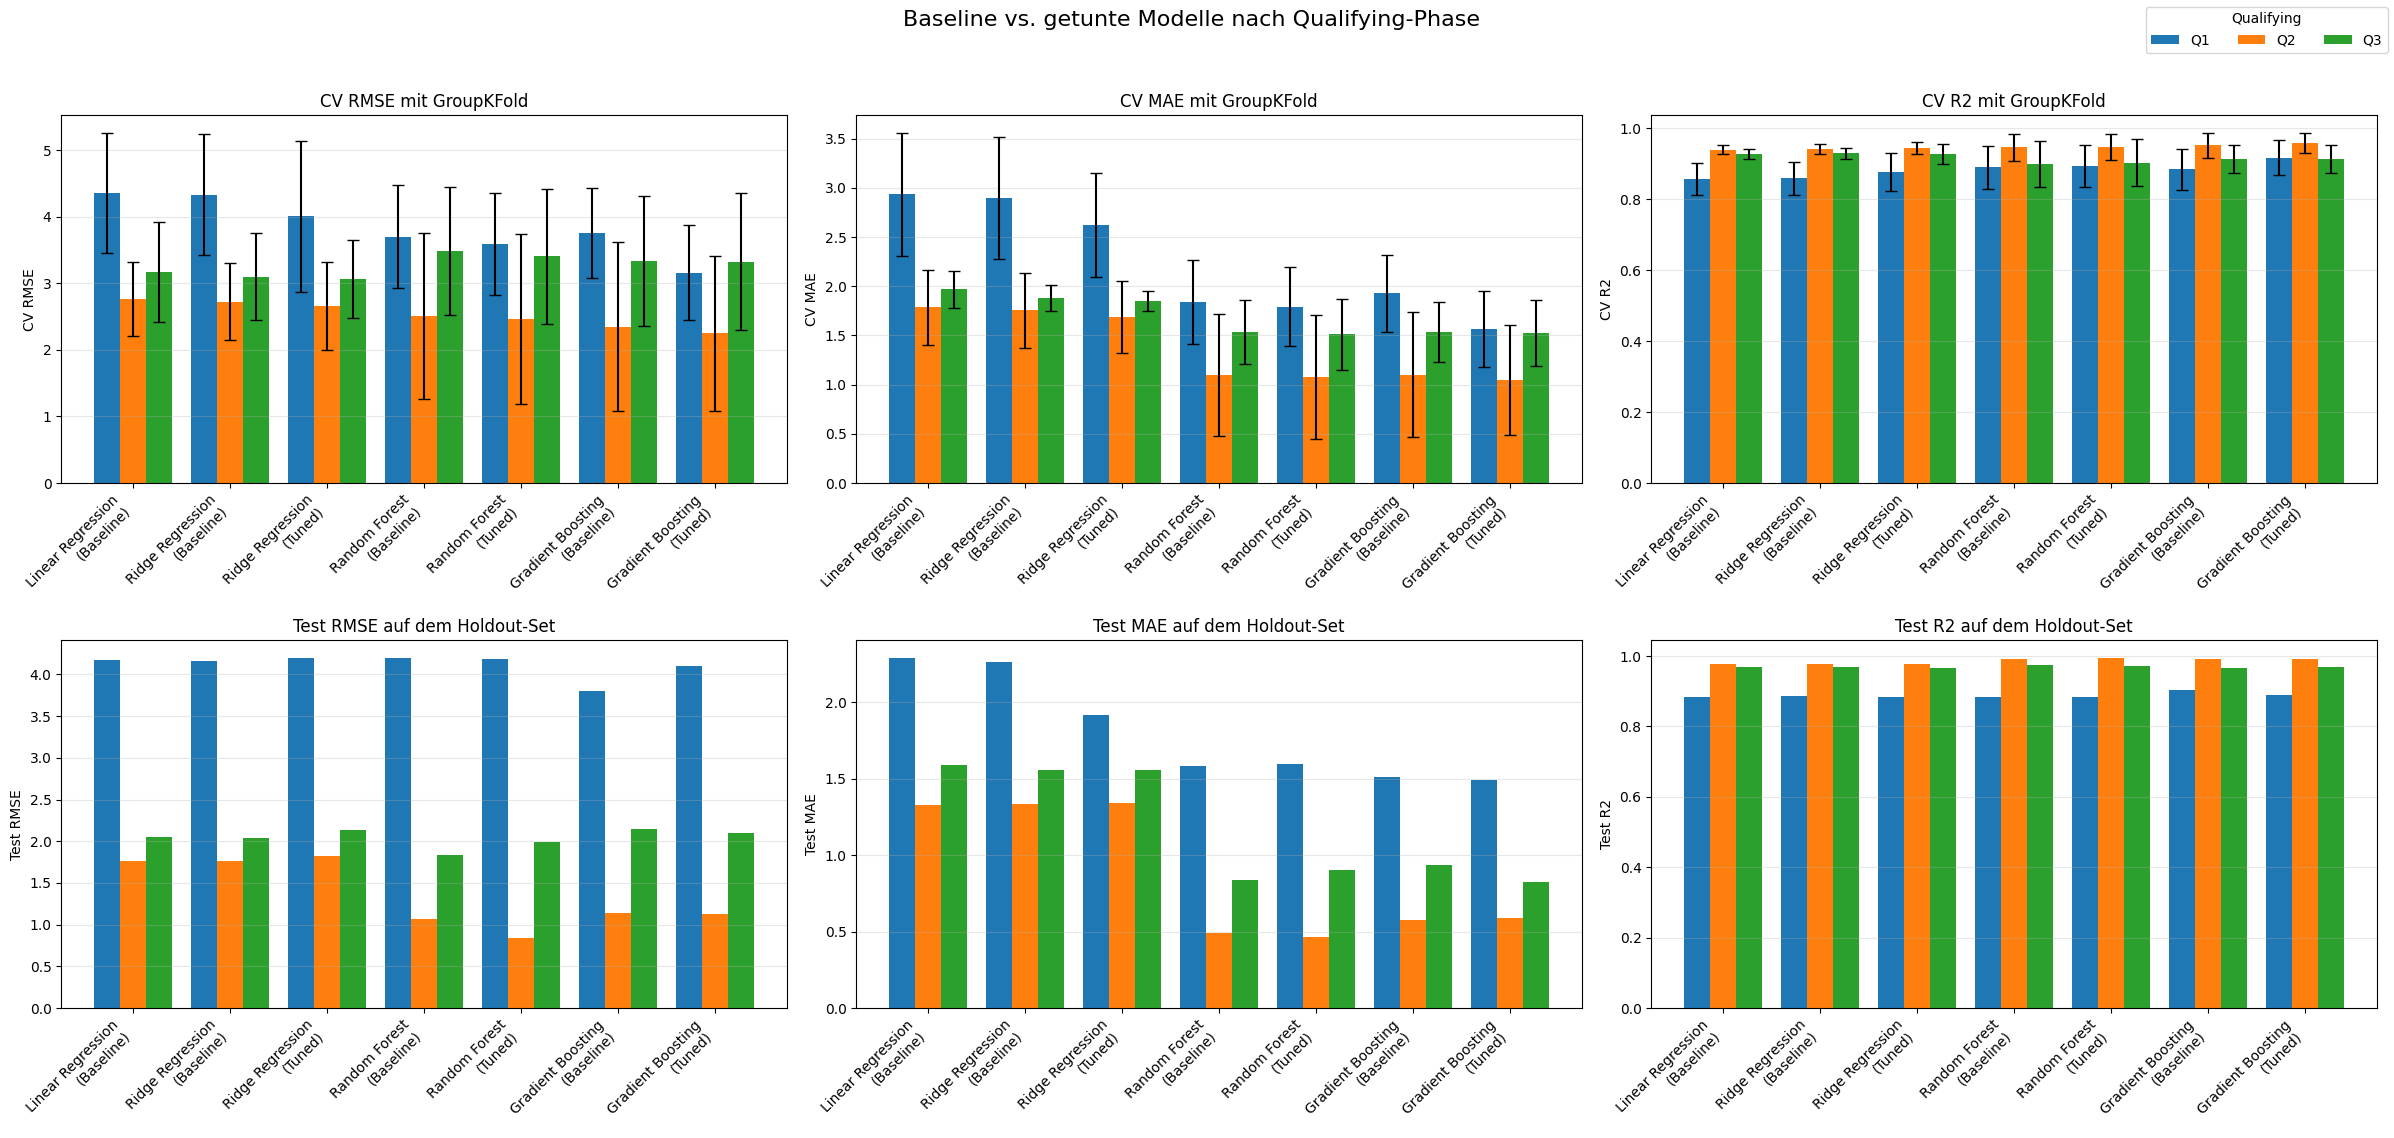

In [21]:
comparison_visualization_df = all_results_df.copy()
comparison_visualization_df["Model_Label"] = (
    comparison_visualization_df["Model"]
    + "\n("
    + comparison_visualization_df["Model_Version"]
    + ")"
)

version_order = {"Baseline": 0, "Tuned": 1}
model_order_map = {model_name: i for i, model_name in enumerate(models.keys())}

model_label_order = (
    comparison_visualization_df[["Model", "Model_Version", "Model_Label"]]
    .drop_duplicates()
    .assign(
        _model_order=lambda df_: df_["Model"].map(model_order_map).fillna(len(model_order_map)),
        _version_order=lambda df_: df_["Model_Version"].map(version_order).fillna(len(version_order)),
    )
    .sort_values(["_model_order", "_version_order", "Model_Label"])
    ["Model_Label"]
    .tolist()
)

comparison_visualization_df["Model_Label"] = pd.Categorical(
    comparison_visualization_df["Model_Label"],
    categories=model_label_order,
    ordered=True,
)
comparison_visualization_df["Qualifying_Phase"] = pd.Categorical(
    comparison_visualization_df["Qualifying_Phase"],
    categories=phase_order,
    ordered=True,
)
comparison_visualization_df = comparison_visualization_df.sort_values([
    "Model_Label",
    "Qualifying_Phase",
])


def plot_baseline_tuned_metric(ax, metric, ylabel, title, yerr_col=None):
    x = np.arange(len(model_label_order))
    width = 0.8 / len(phase_order)

    for i, quali_phase in enumerate(phase_order):
        phase_results = (
            comparison_visualization_df[
                comparison_visualization_df["Qualifying_Phase"] == quali_phase
            ]
            .set_index("Model_Label")
            .reindex(model_label_order)
        )
        offset = (i - (len(phase_order) - 1) / 2) * width
        yerr = phase_results[yerr_col] if yerr_col else None

        ax.bar(
            x + offset,
            phase_results[metric],
            width=width,
            yerr=yerr,
            capsize=4 if yerr_col else 0,
            label=quali_phase,
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(model_label_order, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)


baseline_tuned_metrics_to_plot = [
    ("CV_RMSE_mean", "CV_RMSE_std", "CV RMSE", "CV RMSE mit GroupKFold"),
    ("CV_MAE_mean", "CV_MAE_std", "CV MAE", "CV MAE mit GroupKFold"),
    ("CV_R2_mean", "CV_R2_std", "CV R2", "CV R2 mit GroupKFold"),
    ("Test_RMSE", None, "Test RMSE", "Test RMSE auf dem Holdout-Set"),
    ("Test_MAE", None, "Test MAE", "Test MAE auf dem Holdout-Set"),
    ("Test_R2", None, "Test R2", "Test R2 auf dem Holdout-Set"),
]

fig, axes = plt.subplots(2, 3, figsize=(24, 11))

for ax, (metric, yerr_col, ylabel, title) in zip(axes.ravel(), baseline_tuned_metrics_to_plot):
    plot_baseline_tuned_metric(
        ax,
        metric=metric,
        yerr_col=yerr_col,
        ylabel=ylabel,
        title=title,
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Qualifying", loc="upper right", ncol=len(phase_order))
fig.suptitle("Baseline vs. getunte Modelle nach Qualifying-Phase", y=1.03, fontsize=16)
plt.tight_layout()
plt.show()


Die Ergebnisse zeigen, dass das Hyperparameter-Tuning bei allen Modellen zu einer leichten Verbesserung der Kreuzvalidierung geführt hat. Die grössten Verbesserungen sind bei Random Forest und Gradient Boosting zu beobachten. Zwischen Kreuzvaliderung und Test-Metriken sind bei den getunten Modellen die gleichen Verhalten wie bei den Baselinemodellen zu erkennen.

### **Q2/Q3-Klassifikation aus vorhergesagten Zeiten für getunte Modelle**

In diesem Abschnitt wird anhand der vorhergesagten Qualifying-Zeiten ermittelt, ob ein Fahrer Q2 oder Q3 erreicht für die getunten Modelle.

Hierzu werden die von den Regressionsmodellen vorhergesagten Zeiten innerhalb jedes Rennwochenendes aufsteigend sortiert. Anschliessend werden die Fahrer anhand ihrer prognostizierten Rangposition klassifiziert. Für die Vorhersage der Q2-Teilnahme werden die schnellsten 15 Fahrer (bzw. 16 Fahrer bei 22 Startern) als qualifiziert betrachtet. Für die Vorhersage der Q3-Teilnahme werden die schnellsten 10 Fahrer als qualifiziert eingestuft. Diese Klassifikation wird anschliessend mit den tatsächlichen Qualifikationsergebnissen verglichen.

In [22]:
tuned_classification_results = []
tuned_classification_tables = {}

for model_name in param_grids:
    for quali_phase, task in classification_tasks.items():
        evaluation = predict_qualification_by_rank(
            model=best_models[model_name][quali_phase],
            X_test=task["X_test"],
            source_df=task["source_df"],
            actual_col=task["actual_col"],
            cutoff_function=task["cutoff_function"],
        )

        tuned_classification_tables[(model_name, quali_phase)] = evaluation
        tuned_classification_results.append({
            "Model": model_name,
            "Model_Version": "Tuned",
            "Qualifying_Phase": quali_phase,
            **classification_metrics(
                evaluation["actual_reached"],
                evaluation["predicted_reached"],
            ),
        })

tuned_classification_results_df = (pd.DataFrame(tuned_classification_results).sort_values(["Qualifying_Phase", "Accuracy"], ascending=[True, False])).reset_index(drop=True)
tuned_classification_results_df[[
    "Model",
    "Model_Version",
    "Qualifying_Phase",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "TN",
    "FP",
    "FN",
    "TP",
]].round(3)


,Model,Model_Version,Qualifying_Phase,Accuracy,Precision,Recall,F1_Score,TN,FP,FN,TP
0,Random Forest,Tuned,Q1,0.768,0.836,0.851,0.844,86,74,66,378
1,Gradient Boosting,Tuned,Q1,0.745,0.821,0.836,0.828,79,81,73,371
2,Ridge Regression,Tuned,Q1,0.735,0.814,0.829,0.821,76,84,76,368
3,Random Forest,Tuned,Q2,0.786,0.830,0.850,0.840,100,51,44,249
4,Gradient Boosting,Tuned,Q2,0.764,0.813,0.833,0.823,95,56,49,244
5,Ridge Regression,Tuned,Q2,0.741,0.797,0.816,0.806,90,61,54,239


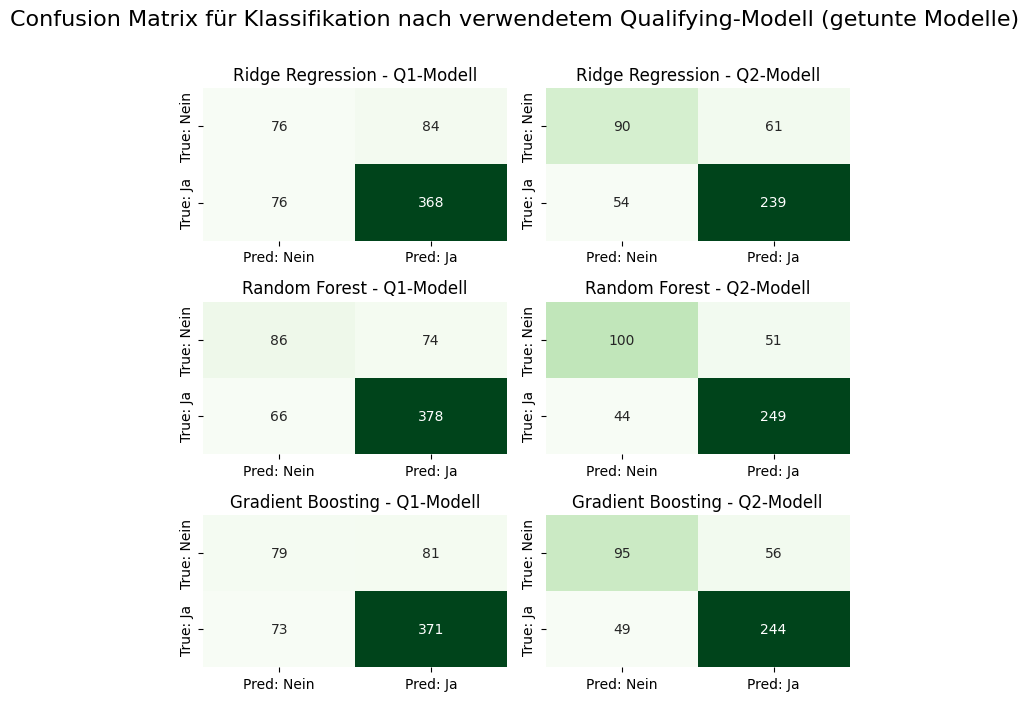

In [23]:
tuned_model_order = list(param_grids.keys())
fig, axes = plt.subplots(len(tuned_model_order), 2, figsize=(7, 2.3 * len(tuned_model_order)))

for row_idx, model_name in enumerate(tuned_model_order):
    for col_idx, quali_phase in enumerate(["Q1", "Q2"]):
        ax = axes[row_idx, col_idx]
        row = tuned_classification_results_df[
            (tuned_classification_results_df["Model"] == model_name)
            & (tuned_classification_results_df["Qualifying_Phase"] == quali_phase)
        ].iloc[0]
        matrix = np.array([
            [row["TN"], row["FP"]],
            [row["FN"], row["TP"]],
        ])

        sns.heatmap(
            matrix,
            annot=True,
            fmt=".0f",
            cmap="Greens",
            cbar=False,
            xticklabels=["Pred: Nein", "Pred: Ja"],
            yticklabels=["True: Nein", "True: Ja"],
            ax=ax,
        )
        ax.set_title(f"{model_name} - {quali_phase}-Modell")
        ax.set_xlabel("")
        ax.set_ylabel("")

fig.suptitle("Confusion Matrix für Klassifikation nach verwendetem Qualifying-Modell (getunte Modelle)", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()


Die Konfusionsmatrizen zeigen, dass alle Modelle deutlich mehr True Positives und True Negatives als Fehlklassifikationen erzeugen.

Insgesamt bestätigen die Klassifikationsergebnisse die Erkenntnisse aus der Regressionsanalyse. Die vorhergesagten Qualifying-Zeiten enthalten genügend Information, um mit hoher Genauigkeit vorherzusagen, welche Fahrer den Einzug in Q2 beziehungsweise Q3 schaffen werden.

### **Vergleich Baseline vs. getunte Modelle für Q2/Q3-Klassifikation**

In [24]:
baseline_classification_results_df = classification_results_df.copy()
baseline_classification_results_df["Model_Version"] = "Baseline"

classification_comparison_df = pd.concat(
    [baseline_classification_results_df, tuned_classification_results_df],
    ignore_index=True,
)

classification_model_order = list(models.keys())
classification_comparison_df = classification_comparison_df[
    classification_comparison_df["Model"].isin(classification_model_order)
].copy()
classification_comparison_df["Qualifying_Phase"] = pd.Categorical(
    classification_comparison_df["Qualifying_Phase"],
    categories=["Q1", "Q2"],
    ordered=True,
)

classification_comparison_table = (
    classification_comparison_df
    .pivot_table(
        index=["Model", "Qualifying_Phase"],
        columns="Model_Version",
        values=["Accuracy", "Precision", "Recall", "F1_Score"],
    )
    .swaplevel(axis=1)
    .sort_index(axis=1, level=0)
)

for metric in ["Accuracy", "Precision", "Recall", "F1_Score"]:
    classification_comparison_table[("Delta_Tuned_minus_Baseline", metric)] = (
        classification_comparison_table[("Tuned", metric)]
        - classification_comparison_table[("Baseline", metric)]
    )

classification_comparison_table.round(3)


C:\Users\Andrin Sutter\AppData\Local\Temp\ipykernel_11104\2182440271.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


Model_Version                      Baseline                            \
                                   Accuracy F1_Score Precision Recall   
Model             Qualifying_Phase                                      
Gradient Boosting Q1                  0.788    0.857     0.850  0.865   
                  Q2                  0.709    0.782     0.773  0.792   
Linear Regression Q1                  0.732    0.819     0.812  0.827   
                  Q2                  0.714    0.786     0.777  0.795   
Random Forest     Q1                  0.758    0.837     0.830  0.845   
                  Q2                  0.764    0.823     0.813  0.833   
Ridge Regression  Q1                  0.732    0.819     0.812  0.827   
                  Q2                  0.709    0.782     0.773  0.792   

Model_Version                         Tuned                            \
                                   Accuracy F1_Score Precision Recall   
Model             Qualifying_Phase                                      
Gradient Boosting Q1                  0.745    0.828     0.821  0.836   
                  Q2                  0.764    0.823     0.813  0.833   
Linear Regression Q1                    NaN      NaN       NaN    NaN   
                  Q2                    NaN      NaN       NaN    NaN   
Random Forest     Q1                  0.768    0.844     0.836  0.851   
                  Q2                  0.786    0.840     0.830  0.850   
Ridge Regression  Q1                  0.735    0.821     0.814  0.829   
                  Q2                  0.741    0.806     0.797  0.816   

Model_Version                      Delta_Tuned_minus_Baseline            \
                                                     Accuracy Precision   
Model             Qualifying_Phase                                        
Gradient Boosting Q1                                   -0.043    -0.029   
                  Q2                                    0.054     0.040   
Linear Regression Q1                                      NaN       NaN   
                  Q2                                      NaN       NaN   
Random Forest     Q1                                    0.010     0.007   
                  Q2                                    0.023     0.017   
Ridge Regression  Q1                                    0.003     0.002   
                  Q2                                    0.032     0.023   

Model_Version                                       
                                   Recall F1_Score  
Model             Qualifying_Phase                  
Gradient Boosting Q1               -0.029   -0.029  
                  Q2                0.041    0.040  
Linear Regression Q1                  NaN      NaN  
                  Q2                  NaN      NaN  
Random Forest     Q1                0.007    0.007  
                  Q2                0.017    0.017  
Ridge Regression  Q1                0.002    0.002  
                  Q2                0.024    0.024

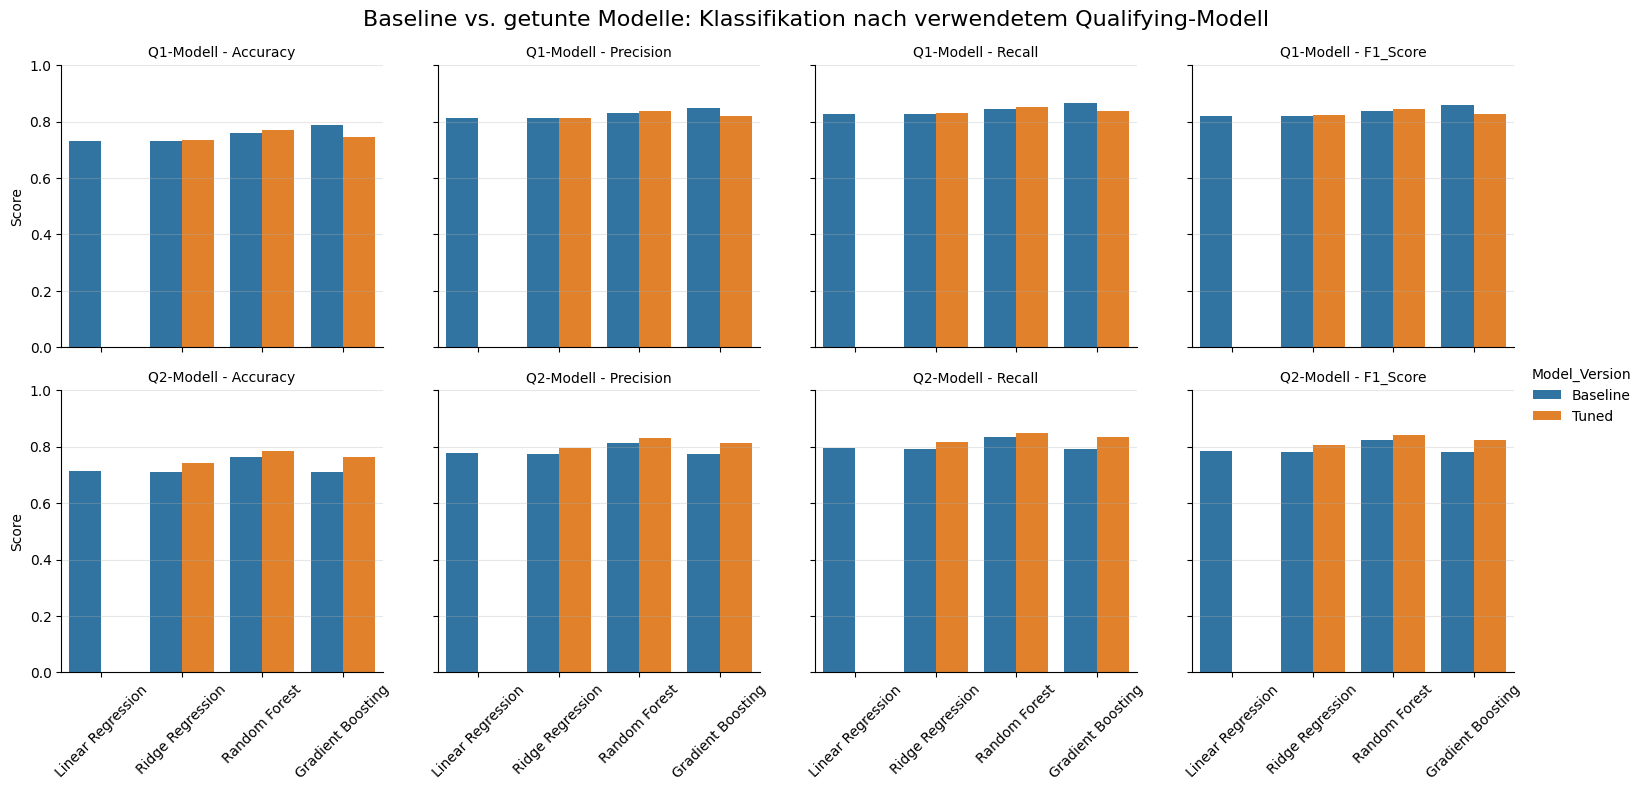

In [25]:
comparison_plot_df = classification_comparison_df.melt(
    id_vars=["Model", "Model_Version", "Qualifying_Phase"],
    value_vars=["Accuracy", "Precision", "Recall", "F1_Score"],
    var_name="Metric",
    value_name="Score",
)

comparison_plot_df["Model"] = pd.Categorical(
    comparison_plot_df["Model"],
    categories=classification_model_order,
    ordered=True,
)
comparison_plot_df["Model_Version"] = pd.Categorical(
    comparison_plot_df["Model_Version"],
    categories=["Baseline", "Tuned"],
    ordered=True,
)
comparison_plot_df["Qualifying_Phase"] = pd.Categorical(
    comparison_plot_df["Qualifying_Phase"],
    categories=["Q1", "Q2"],
    ordered=True,
)

g = sns.catplot(
    data=comparison_plot_df,
    x="Model",
    y="Score",
    hue="Model_Version",
    col="Metric",
    row="Qualifying_Phase",
    kind="bar",
    height=3.5,
    aspect=1.1,
    sharey=True,
)

g.set_axis_labels("", "Score")
g.set_titles("{row_name}-Modell - {col_name}")
g.set(ylim=(0, 1))

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

g.fig.suptitle("Baseline vs. getunte Modelle: Klassifikation nach verwendetem Qualifying-Modell", y=1.03, fontsize=16)
plt.show()


Grösstenteils sind die getunten Modelle besser als die Baseline-Modelle.

### **Ensemble der besten Modelle pro Qualifying-Phase**

Da der Unterschied zwischen den Baselinemodellen und den getunten Modellen nur minimal war, wird in diesem Abschnitt für jeden Qualifying-Abschnitt ein Ensemble Modell erstellt. Ziel ist es, mehrere gute Einzelmodelle zu einem gemeinsamen Modell zusammenzuführen, um stabilere und möglicherweise genauere Vorhersagen zu erhalten.

Dafür wird ein eigener AveragingRegressor definiert. Dieses Modell trainiert mehrere Regressionsmodelle parallel auf denselben Trainingsdaten. Bei der Vorhersage berechnet jedes Einzelmodell zunächst eine eigene Prognose. Anschliessend werden diese Vorhersagen gemittelt. Die finale Vorhersage entspricht somit dem Durchschnitt der Einzelvorhersagen.

Für jede Qualifying-Phase werden zuerst die besten Modellvarianten anhand des kreuzvalidierten RMSE ausgewählt. Dabei wird pro Modellklasse jeweils nur die beste Variante berücksichtigt, also entweder das Baseline-Modell oder das getunte Modell. Anschliessend werden die drei besten Modelle zu einem Averaging Ensemble kombiniert.

Dieses Vorgehen hat den Vorteil, dass unterschiedliche Modelltypen ihre jeweiligen Stärken einbringen können. Lineare Modelle können einfache Zusammenhänge stabil erfassen, während Methoden wie Random Forest oder Gradient Boosting nichtlineare Zusammenhänge besser modellieren können. Durch die Mittelung der Vorhersagen kann die Abhängigkeit von einem einzelnen Modell reduziert werden.

Das resultierende Ensemble wird anschliessend mit demselben Bewertungsworkflow wie die bisherigen Einzelmodelle untersucht. Dadurch können die Ergebnisse direkt mit den Baseline- und den getunten Modellen verglichen werden.

In [26]:
class AveragingRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, estimators, weights=None):
        self.estimators = estimators
        self.weights = weights

    def fit(self, X, y):
        self.fitted_estimators_ = [
            (name, clone(model).fit(X, y))
            for name, model in self.estimators
        ]
        return self

    def predict(self, X):
        predictions = np.column_stack([
            model.predict(X)
            for _, model in self.fitted_estimators_
        ])
        return np.average(predictions, axis=1, weights=self.weights)


def model_from_result_row(row):
    model_name = row["Model"]
    quali_phase = row["Qualifying_Phase"]

    if row["Model_Version"] == "Baseline":
        return fitted_models[model_name][quali_phase]
    if row["Model_Version"] == "Tuned":
        return best_models[model_name][quali_phase]

    raise ValueError(f"Unbekannte Modellversion: {row['Model_Version']}")


def get_top_models_for_phase(results_df, phase, top_n=3):
    phase_rows = results_df[results_df["Qualifying_Phase"] == phase].copy()

    best_variant_per_model = (
        phase_rows
        .sort_values(["Model", "CV_RMSE_mean"], ascending=[True, True])
        .groupby("Model", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    top_rows = (
        best_variant_per_model
        .sort_values("CV_RMSE_mean", ascending=True)
        .head(top_n)
    )

    estimators = [
        (f"{row['Model']} ({row['Model_Version']})", model_from_result_row(row))
        for _, row in top_rows.iterrows()
    ]

    return estimators, top_rows


ensemble_models = {}
ensemble_results = []
ensemble_base_model_rows = {}

for quali_phase, data in datasets.items():
    estimators, top_rows = get_top_models_for_phase(
        all_results_df,
        quali_phase,
        top_n=3,
    )

    ensemble = AveragingRegressor(estimators=estimators)
    result, fitted_ensemble = evaluate_model(
        model=ensemble,
        model_name="Averaging Ensemble",
        X_train=data["X_train"],
        y_train=data["y_train"],
        X_test=data["X_test"],
        y_test=data["y_test"],
        cv_splits=5,
    )

    result["Model_Version"] = "Ensemble"
    result["Qualifying_Phase"] = quali_phase
    result["Base_Models"] = ", ".join(
        f"{row['Model']} ({row['Model_Version']})"
        for _, row in top_rows.iterrows()
    )
    result["Best_Params"] = None

    ensemble_results.append(result)
    ensemble_models[quali_phase] = fitted_ensemble
    ensemble_base_model_rows[quali_phase] = top_rows

ensemble_results_df = pd.DataFrame(ensemble_results)

In [27]:
final_results_df = (
    pd.concat([all_results_df, ensemble_results_df], ignore_index=True, sort=False)
    .sort_values(["Qualifying_Phase", "CV_RMSE_mean", "Model_Version"], ascending=[True, True, True])
    .reset_index(drop=True)
)

final_results_df[[
    "Model",
    "Model_Version",
    "Qualifying_Phase",
    "CV_RMSE_mean",
    "CV_RMSE_std",
    "CV_MAE_mean",
    "CV_MAE_std",
    "CV_R2_mean",
    "CV_R2_std",
    "Test_RMSE",
    "Test_MAE",
    "Test_R2",
    "Best_Params",
    "Base_Models",
]].round(3)

,Model,Model_Version,Qualifying_Phase,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,Test_RMSE,Test_MAE,Test_R2,Best_Params,Base_Models
0,Gradient Boosting,Tuned,Q1,3.164,0.713,1.564,0.389,0.916,0.049,4.104,1.491,0.889,"{'model__learning_rate': 0.05, 'model__max_dep...",None
1,Averaging Ensemble,Ensemble,Q1,3.164,0.820,1.726,0.371,0.920,0.041,4.091,1.534,0.889,None,"Gradient Boosting (Tuned), Random Forest (Tune..."
2,Random Forest,Tuned,Q1,3.596,0.768,1.793,0.403,0.893,0.059,4.181,1.597,0.884,"{'model__max_depth': 10, 'model__min_samples_l...",None
3,Random Forest,Baseline,Q1,3.705,0.778,1.839,0.430,0.889,0.060,4.199,1.585,0.883,None,None
4,Gradient Boosting,Baseline,Q1,3.765,0.676,1.928,0.393,0.885,0.057,3.807,1.512,0.904,None,None
5,Ridge Regression,Tuned,Q1,4.009,1.136,2.622,0.529,0.878,0.053,4.198,1.914,0.883,{'model__alpha': 100},None
6,Ridge Regression,Baseline,Q1,4.333,0.908,2.899,0.623,0.859,0.046,4.165,2.261,0.885,None,None
7,Linear Regression,Baseline,Q1,4.360,0.905,2.935,0.625,0.857,0.045,4.176,2.291,0.885,None,None
8,Averaging Ensemble,Ensemble,Q2,2.195,0.942,1.104,0.413,0.962,0.020,0.980,0.644,0.993,None,"Gradient Boosting (Tuned), Random Forest (Tune..."
9,Gradient Boosting,Tuned,Q2,2.249,1.161,1.046,0.561,0.958,0.029,1.126,0.591,0.991,"{'model__learning_rate': 0.05, 'model__max_dep...",None


### **Visualisierung der Ergebnisse mit Ensemble**

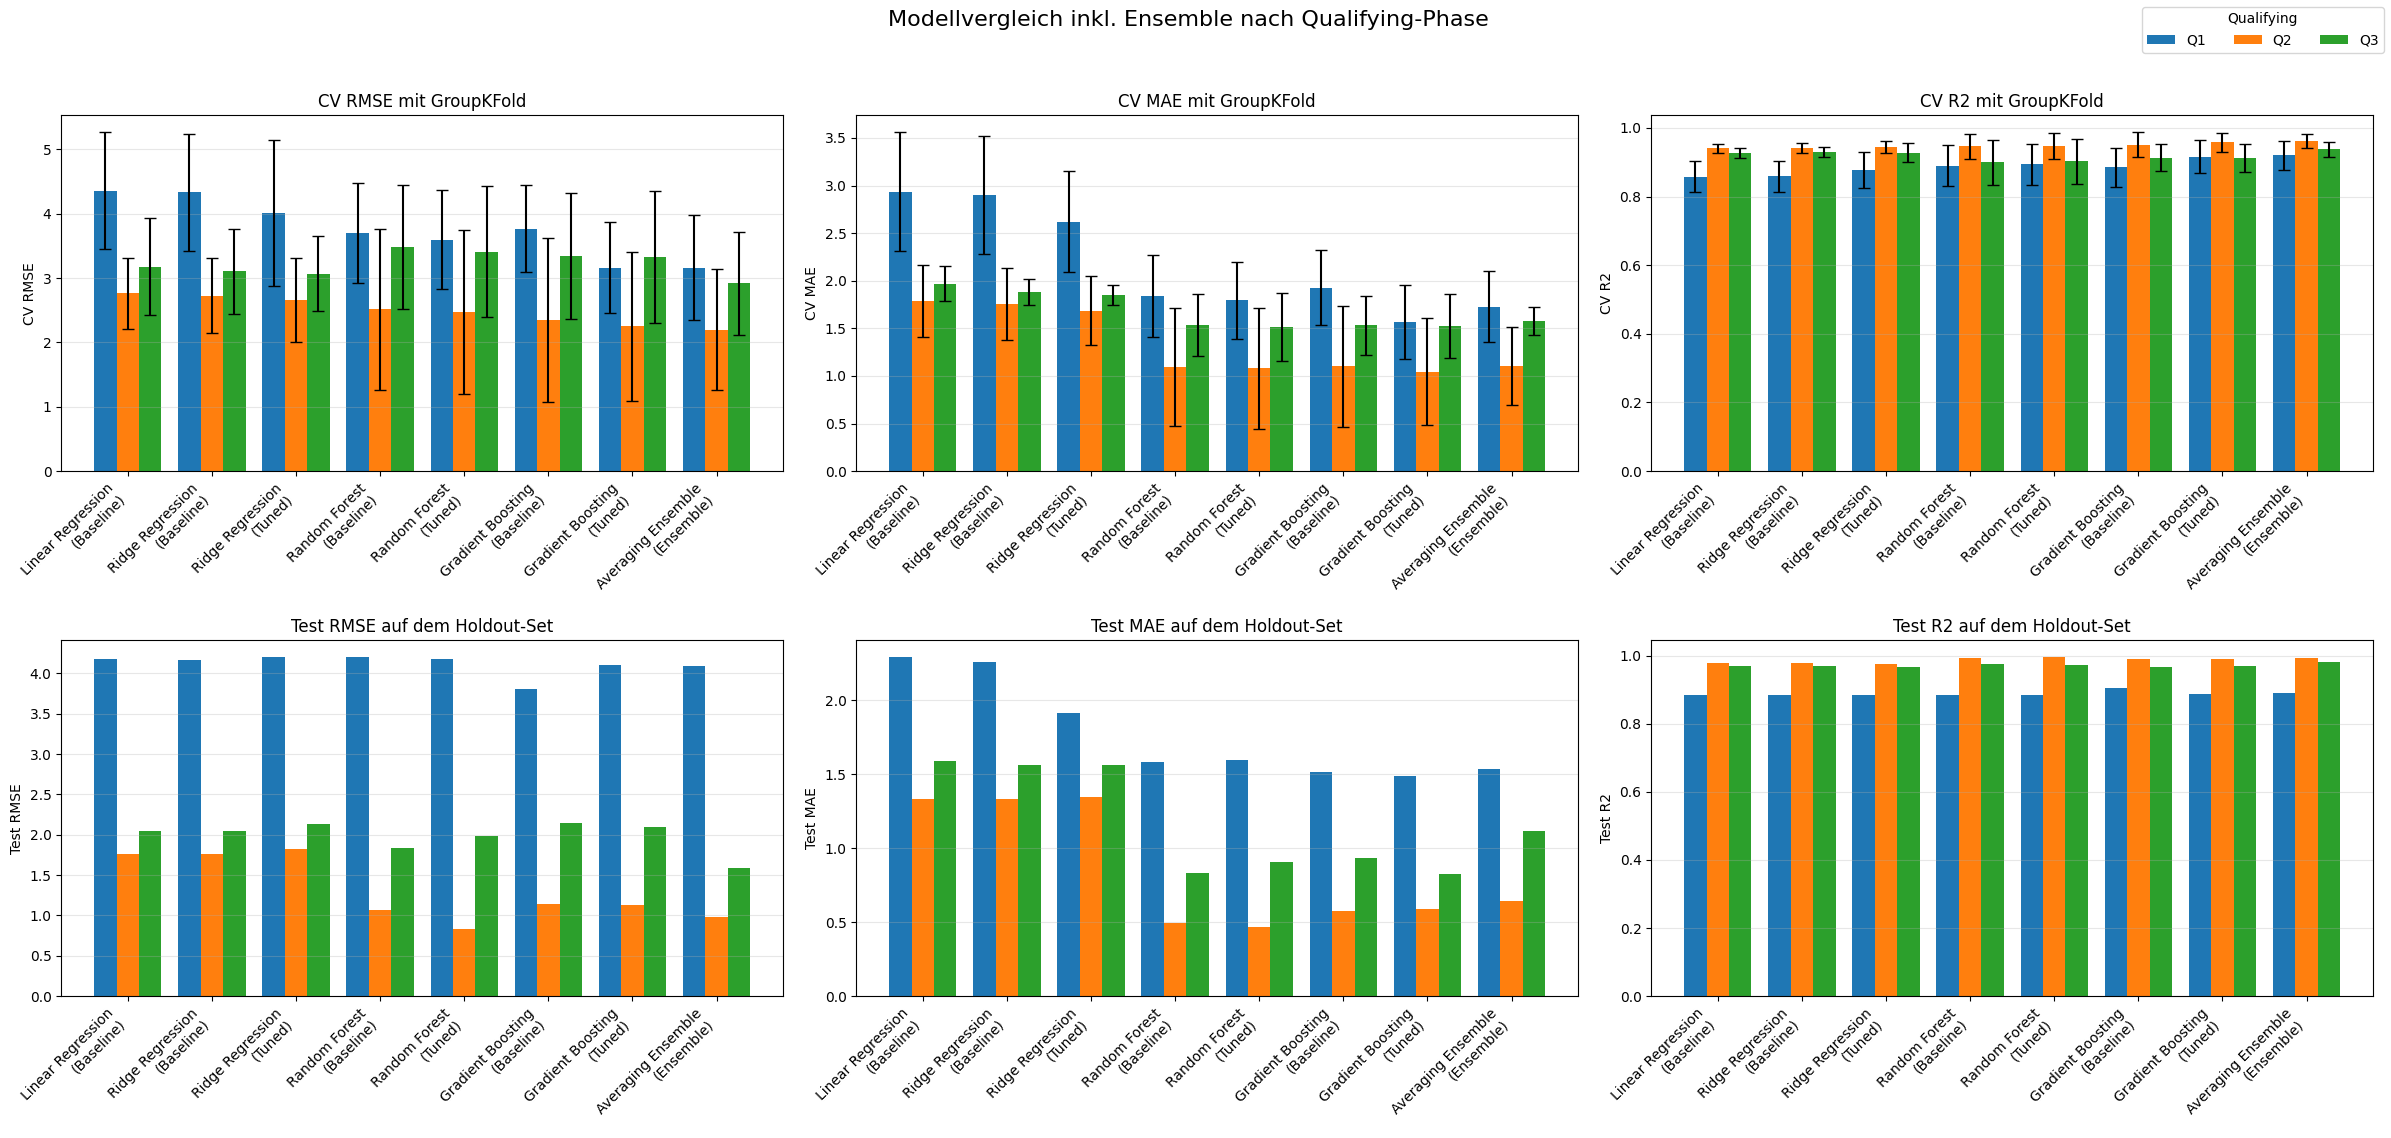

In [28]:
ensemble_visualization_df = final_results_df.copy()
ensemble_visualization_df["Model_Label"] = (
    ensemble_visualization_df["Model"]
    + "\n("
    + ensemble_visualization_df["Model_Version"]
    + ")"
)

version_order = {"Baseline": 0, "Tuned": 1, "Ensemble": 2}
model_order_map = {model_name: i for i, model_name in enumerate(models.keys())}
model_order_map["Averaging Ensemble"] = len(model_order_map)

model_label_order = (
    ensemble_visualization_df[["Model", "Model_Version", "Model_Label"]]
    .drop_duplicates()
    .assign(
        _model_order=lambda df_: df_["Model"].map(model_order_map).fillna(len(model_order_map)),
        _version_order=lambda df_: df_["Model_Version"].map(version_order).fillna(len(version_order)),
    )
    .sort_values(["_model_order", "_version_order", "Model_Label"])
    ["Model_Label"]
    .tolist()
)

ensemble_visualization_df["Model_Label"] = pd.Categorical(
    ensemble_visualization_df["Model_Label"],
    categories=model_label_order,
    ordered=True,
)
ensemble_visualization_df["Qualifying_Phase"] = pd.Categorical(
    ensemble_visualization_df["Qualifying_Phase"],
    categories=phase_order,
    ordered=True,
)
ensemble_visualization_df = ensemble_visualization_df.sort_values([
    "Model_Label",
    "Qualifying_Phase",
])


def plot_grouped_metric_with_ensemble(ax, metric, ylabel, title, yerr_col=None):
    x = np.arange(len(model_label_order))
    width = 0.8 / len(phase_order)

    for i, quali_phase in enumerate(phase_order):
        phase_results = (
            ensemble_visualization_df[ensemble_visualization_df["Qualifying_Phase"] == quali_phase]
            .set_index("Model_Label")
            .reindex(model_label_order)
        )
        offset = (i - (len(phase_order) - 1) / 2) * width
        yerr = phase_results[yerr_col] if yerr_col else None

        ax.bar(
            x + offset,
            phase_results[metric],
            width=width,
            yerr=yerr,
            capsize=4 if yerr_col else 0,
            label=quali_phase,
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(model_label_order, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)


metrics_to_plot_with_ensemble = [
    ("CV_RMSE_mean", "CV_RMSE_std", "CV RMSE", "CV RMSE mit GroupKFold"),
    ("CV_MAE_mean", "CV_MAE_std", "CV MAE", "CV MAE mit GroupKFold"),
    ("CV_R2_mean", "CV_R2_std", "CV R2", "CV R2 mit GroupKFold"),
    ("Test_RMSE", None, "Test RMSE", "Test RMSE auf dem Holdout-Set"),
    ("Test_MAE", None, "Test MAE", "Test MAE auf dem Holdout-Set"),
    ("Test_R2", None, "Test R2", "Test R2 auf dem Holdout-Set"),
]

fig, axes = plt.subplots(2, 3, figsize=(24, 11))

for ax, (metric, yerr_col, ylabel, title) in zip(axes.ravel(), metrics_to_plot_with_ensemble):
    plot_grouped_metric_with_ensemble(
        ax,
        metric=metric,
        yerr_col=yerr_col,
        ylabel=ylabel,
        title=title,
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Qualifying", loc="upper right", ncol=len(phase_order))
fig.suptitle("Modellvergleich inkl. Ensemble nach Qualifying-Phase", y=1.03, fontsize=16)
plt.tight_layout()
plt.show()

Die Ergebnisse zeigen, dass das Averaging-Ensemble insbesondere bei den Holdout-Testdaten eine sehr hohe Vorhersagegüte erreicht. Für die Vorhersage der Q3-Zeit erzielt das Averaging-Ensemble den niedrigsten RMSE und MAE sowie den höchsten R²-Wert aller untersuchten Modelle. Auch für die Vorhersagen von Q1 und Q2 liegt die Leistung auf dem Niveau der besten Einzelmodelle. Gleichzeitig zeigen die Kreuzvalidierungsergebnisse eine geringe Streuung der Fehlerkennzahlen, was auf eine gute Generalisierungsfähigkeit hinweist.

### **Q2/Q3-Klassifikation mit Ensemble**

Die bisherige Klassifikation, ob ein Fahrer Q2 oder Q3 erreicht, wird um die Averaging-Ensemble ergänzt.

In [29]:
ensemble_classification_results = []
ensemble_classification_tables = {}

for quali_phase, task in classification_tasks.items():
    evaluation = predict_qualification_by_rank(
        model=ensemble_models[quali_phase],
        X_test=task["X_test"],
        source_df=task["source_df"],
        actual_col=task["actual_col"],
        cutoff_function=task["cutoff_function"],
    )

    ensemble_classification_tables[("Averaging Ensemble", quali_phase)] = evaluation
    ensemble_classification_results.append({
        "Model": "Averaging Ensemble",
        "Model_Version": "Ensemble",
        "Qualifying_Phase": quali_phase,
        **classification_metrics(
            evaluation["actual_reached"],
            evaluation["predicted_reached"],
        ),
    })

ensemble_classification_results_df = pd.DataFrame(ensemble_classification_results)

final_classification_comparison_df = pd.concat(
    [classification_comparison_df, ensemble_classification_results_df],
    ignore_index=True,
)

final_classification_model_order = classification_model_order + ["Averaging Ensemble"]
final_classification_version_order = ["Baseline", "Tuned", "Ensemble"]

final_classification_comparison_df["Model"] = pd.Categorical(
    final_classification_comparison_df["Model"],
    categories=final_classification_model_order,
    ordered=True,
)
final_classification_comparison_df["Model_Version"] = pd.Categorical(
    final_classification_comparison_df["Model_Version"],
    categories=final_classification_version_order,
    ordered=True,
)
final_classification_comparison_df["Qualifying_Phase"] = pd.Categorical(
    final_classification_comparison_df["Qualifying_Phase"],
    categories=["Q1", "Q2"],
    ordered=True,
)
final_classification_comparison_df = (
    final_classification_comparison_df
    .sort_values(["Qualifying_Phase", "Accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)

final_classification_comparison_df[[
    "Model",
    "Model_Version",
    "Qualifying_Phase",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "TN",
    "FP",
    "FN",
    "TP",
]].round(3)


,Model,Model_Version,Qualifying_Phase,Accuracy,Precision,Recall,F1_Score,TN,FP,FN,TP
0,Gradient Boosting,Baseline,Q1,0.788,0.850,0.865,0.857,92,68,60,384
1,Random Forest,Tuned,Q1,0.768,0.836,0.851,0.844,86,74,66,378
2,Averaging Ensemble,Ensemble,Q1,0.762,0.832,0.847,0.839,84,76,68,376
3,Random Forest,Baseline,Q1,0.758,0.830,0.845,0.837,83,77,69,375
4,Gradient Boosting,Tuned,Q1,0.745,0.821,0.836,0.828,79,81,73,371
5,Ridge Regression,Tuned,Q1,0.735,0.814,0.829,0.821,76,84,76,368
6,Linear Regression,Baseline,Q1,0.732,0.812,0.827,0.819,75,85,77,367
7,Ridge Regression,Baseline,Q1,0.732,0.812,0.827,0.819,75,85,77,367
8,Random Forest,Tuned,Q2,0.786,0.830,0.850,0.840,100,51,44,249
9,Random Forest,Baseline,Q2,0.764,0.813,0.833,0.823,95,56,49,244


Die Ergebnisse zeigen, dass das Averaging Ensemble bei der Klassifikation keinen zusätzlichen Vorteil gegenüber den besten Einzelmodellen erzielt. Für die Vorhersage des Einzugs in Q2 erreicht das Ensemble eine Accuracy von 76.2 % sowie einen F1-Score von 0.839. Auch bei der Q3-Klassifikation kann das Ensemble keine Verbesserung erzielen. Mit einer Accuracy von 74.5 % und einem F1-Score von 0.809.

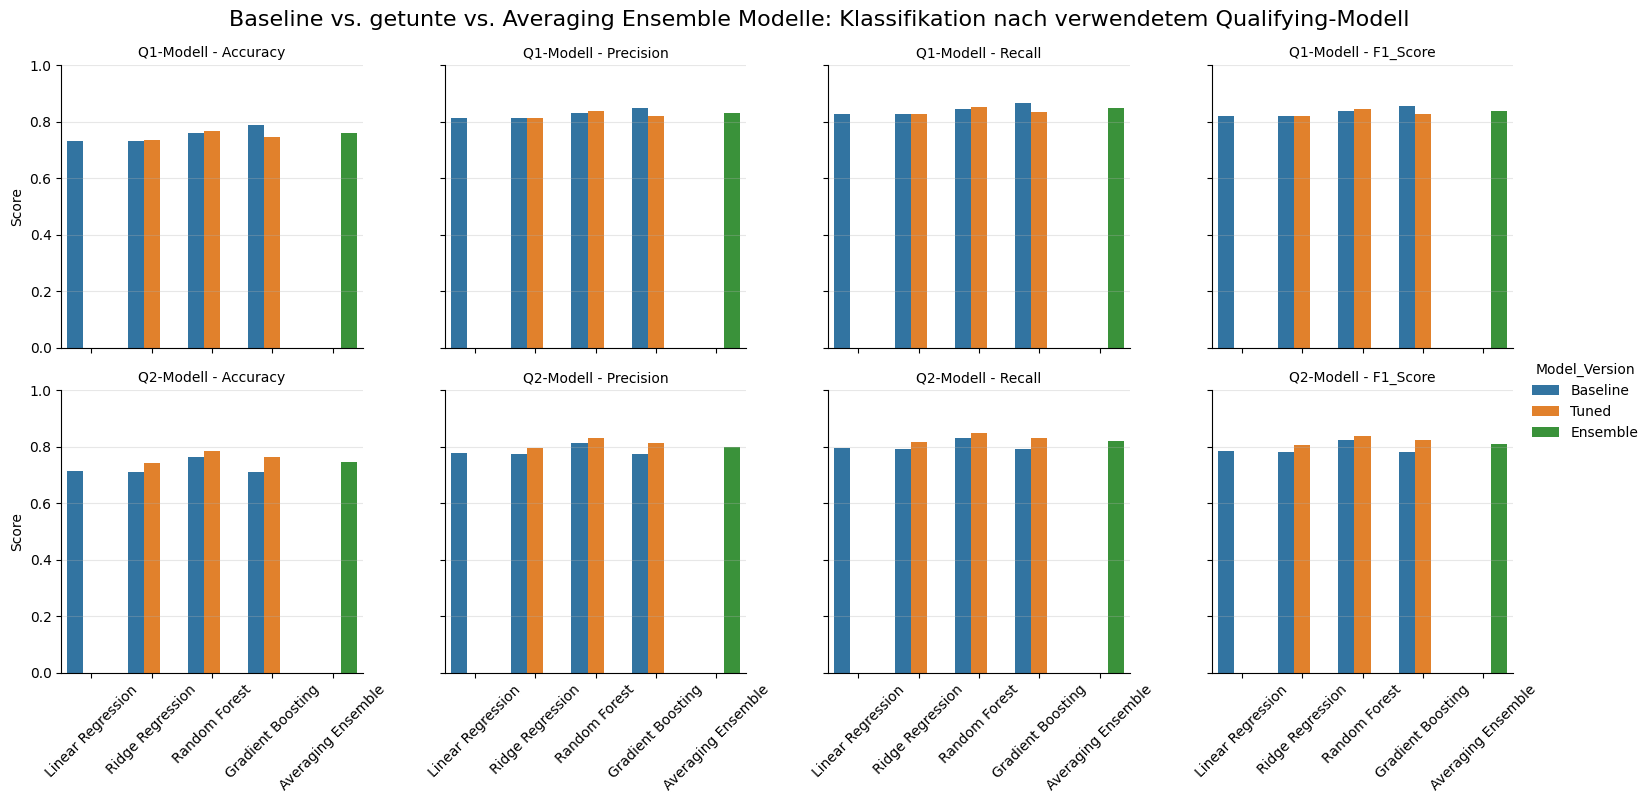

In [30]:
final_comparison_plot_df = final_classification_comparison_df.melt(
    id_vars=["Model", "Model_Version", "Qualifying_Phase"],
    value_vars=["Accuracy", "Precision", "Recall", "F1_Score"],
    var_name="Metric",
    value_name="Score",
)

final_comparison_plot_df["Model"] = pd.Categorical(
    final_comparison_plot_df["Model"],
    categories=final_classification_model_order,
    ordered=True,
)
final_comparison_plot_df["Model_Version"] = pd.Categorical(
    final_comparison_plot_df["Model_Version"],
    categories=["Baseline", "Tuned", "Ensemble"],
    ordered=True,
)
final_comparison_plot_df["Qualifying_Phase"] = pd.Categorical(
    final_comparison_plot_df["Qualifying_Phase"],
    categories=["Q1", "Q2"],
    ordered=True,
)

g = sns.catplot(
    data=final_comparison_plot_df,
    x="Model",
    y="Score",
    hue="Model_Version",
    col="Metric",
    row="Qualifying_Phase",
    kind="bar",
    height=3.5,
    aspect=1.1,
    sharey=True,
)

g.set_axis_labels("", "Score")
g.set_titles("{row_name}-Modell - {col_name}")
g.set(ylim=(0, 1))

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

g.fig.suptitle("Baseline vs. getunte vs. Averaging Ensemble Modelle: Klassifikation nach verwendetem Qualifying-Modell", y=1.03, fontsize=16)
plt.show()

### **Confusion Matrix für Q2/Q3-Klassifikation inkl. Ensemble**

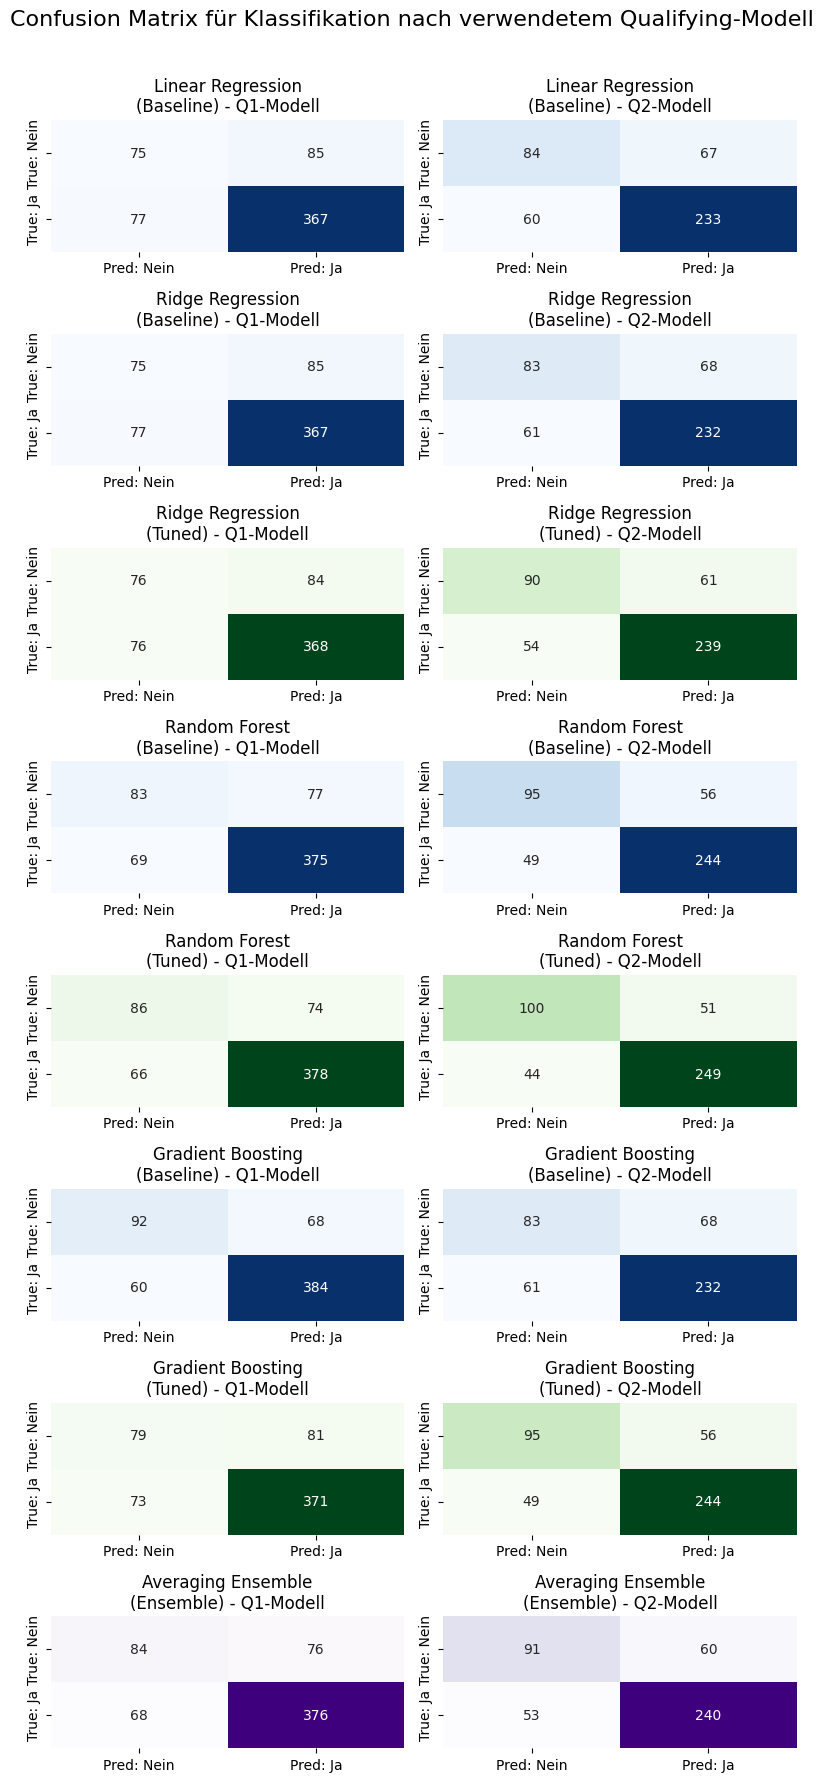

In [31]:
classification_matrix_df = final_classification_comparison_df.copy()
classification_matrix_df["Model_Label"] = (
    classification_matrix_df["Model"].astype(str)
    + "\n("
    + classification_matrix_df["Model_Version"].astype(str)
    + ")"
)

classification_matrix_order = (
    classification_matrix_df[["Model", "Model_Version", "Model_Label"]]
    .drop_duplicates()
    .sort_values(["Model", "Model_Version"])
    ["Model_Label"]
    .tolist()
)

version_cmaps = {
    "Baseline": "Blues",
    "Tuned": "Greens",
    "Ensemble": "Purples",
}

fig, axes = plt.subplots(
    len(classification_matrix_order),
    2,
    figsize=(8, 2.2 * len(classification_matrix_order)),
    squeeze=False,
)

for row_idx, model_label in enumerate(classification_matrix_order):
    label_rows = classification_matrix_df[classification_matrix_df["Model_Label"] == model_label]
    model_version = label_rows["Model_Version"].iloc[0]

    for col_idx, quali_phase in enumerate(["Q1", "Q2"]):
        ax = axes[row_idx, col_idx]
        phase_rows = label_rows[label_rows["Qualifying_Phase"] == quali_phase]

        if phase_rows.empty:
            ax.axis("off")
            continue

        row = phase_rows.iloc[0]
        matrix = np.array([
            [row["TN"], row["FP"]],
            [row["FN"], row["TP"]],
        ])

        sns.heatmap(
            matrix,
            annot=True,
            fmt=".0f",
            cmap=version_cmaps.get(str(model_version), "Greys"),
            cbar=False,
            xticklabels=["Pred: Nein", "Pred: Ja"],
            yticklabels=["True: Nein", "True: Ja"],
            ax=ax,
        )
        ax.set_title(f"{model_label} - {quali_phase}-Modell")
        ax.set_xlabel("")
        ax.set_ylabel("")

fig.suptitle("Confusion Matrix für Klassifikation nach verwendetem Qualifying-Modell", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()


Die Konfusionsmatrix bestätigt dieses Verhalten. Während die Ensemble-Modelle bei der Vorhersage der Qualifying-Zeiten teilweise von der Kombination mehrerer Modelle profitieren konnten, führt die anschliessende Rangbildung zur Bestimmung der Q2- und Q3-Teilnahme nicht zu einer weiteren Verbesserung der Klassifikation. Die Anzahl korrekt klassifizierter Fahrer bleibt gegenüber den besten Einzelmodellen nahezu unverändert.

# **Entscheid**

Nun wurden für jeden Qualifying-Abschnitt 8 Modelle trainiert. Im folgenden sind nochmals die Ergebnisse zu allen Modellen zusammen getragen.

In [32]:
from IPython.display import HTML

candidate_results_df = final_results_df.copy()

classification_decision_df = final_classification_comparison_df[[
    "Model",
    "Model_Version",
    "Qualifying_Phase",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "TN",
    "FP",
    "FN",
    "TP",
]]

candidate_results_df = candidate_results_df.merge(
    classification_decision_df,
    on=["Model", "Model_Version", "Qualifying_Phase"],
    how="left",
)

decision_result_columns = [
    "Qualifying_Phase",
    "Model",
    "Model_Version",
    "CV_RMSE_mean",
    "CV_RMSE_std",
    "CV_MAE_mean",
    "CV_MAE_std",
    "CV_R2_mean",
    "CV_R2_std",
    "Test_RMSE",
    "Test_MAE",
    "Test_R2",
    "Accuracy",
    "Precision",
    "Recall",
    "F1_Score",
    "TN",
    "FP",
    "FN",
    "TP",
]

all_decision_results_df = (
    candidate_results_df[decision_result_columns]
    .sort_values(["Qualifying_Phase", "CV_RMSE_mean", "Model_Version"], ascending=[True, True, True])
    .reset_index(drop=True)
)


def highlight_best_values(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    lower_is_better = [
        "CV_RMSE_mean",
        "CV_RMSE_std",
        "CV_MAE_mean",
        "CV_MAE_std",
        "CV_R2_std",
        "Test_RMSE",
        "Test_MAE",
        "FP",
        "FN",
    ]
    higher_is_better = [
        "CV_R2_mean",
        "Test_R2",
        "Accuracy",
        "Precision",
        "Recall",
        "F1_Score",
        "TN",
        "TP",
    ]

    for _, phase_results in data.groupby("Qualifying_Phase", observed=True):
        for column in lower_is_better:
            best_value = phase_results[column].min(skipna=True)
            if pd.notna(best_value):
                styles.loc[phase_results.index[phase_results[column] == best_value], column] = "background-color: gold; color: black"

        for column in higher_is_better:
            best_value = phase_results[column].max(skipna=True)
            if pd.notna(best_value):
                styles.loc[phase_results.index[phase_results[column] == best_value], column] = "background-color: gold; color: black"

    return styles

def display_highlighted_table(data, title):
    styles = highlight_best_values(data)
    formatted_data = data.round(3)

    html = [f"<h4>{title}</h4>"]
    html.append('<table border="1" class="dataframe">')
    html.append("<thead><tr>")
    for column in formatted_data.columns:
        html.append(f"<th>{column}</th>")
    html.append("</tr></thead><tbody>")

    for idx, row in formatted_data.iterrows():
        html.append("<tr>")
        for column, value in row.items():
            style = styles.loc[idx, column]
            style_attr = f' style="{style}"' if style else ""
            if pd.isna(value):
                value = ""
            html.append(f"<td{style_attr}>{value}</td>")
        html.append("</tr>")

    html.append("</tbody></table>")
    display(HTML("".join(html)))


display_highlighted_table(
    all_decision_results_df,
    "Alle Modelle mit allen Ergebnissen",
)

best_model_summary = (
    candidate_results_df
    .sort_values(["Qualifying_Phase", "CV_RMSE_mean"], ascending=[True, True])
    .groupby("Qualifying_Phase", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

Qualifying_Phase,Model,Model_Version,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,Test_RMSE,Test_MAE,Test_R2,Accuracy,Precision,Recall,F1_Score,TN,FP,FN,TP
Q1,Gradient Boosting,Tuned,3.164,0.713,1.564,0.389,0.916,0.049,4.104,1.491,0.889,0.745,0.821,0.836,0.828,79.0,81.0,73.0,371.0
Q1,Averaging Ensemble,Ensemble,3.164,0.82,1.726,0.371,0.92,0.041,4.091,1.534,0.889,0.762,0.832,0.847,0.839,84.0,76.0,68.0,376.0
Q1,Random Forest,Tuned,3.596,0.768,1.793,0.403,0.893,0.059,4.181,1.597,0.884,0.768,0.836,0.851,0.844,86.0,74.0,66.0,378.0
Q1,Random Forest,Baseline,3.705,0.778,1.839,0.43,0.889,0.06,4.199,1.585,0.883,0.758,0.83,0.845,0.837,83.0,77.0,69.0,375.0
Q1,Gradient Boosting,Baseline,3.765,0.676,1.928,0.393,0.885,0.057,3.807,1.512,0.904,0.788,0.85,0.865,0.857,92.0,68.0,60.0,384.0
Q1,Ridge Regression,Tuned,4.009,1.136,2.622,0.529,0.878,0.053,4.198,1.914,0.883,0.735,0.814,0.829,0.821,76.0,84.0,76.0,368.0
Q1,Ridge Regression,Baseline,4.333,0.908,2.899,0.623,0.859,0.046,4.165,2.261,0.885,0.732,0.812,0.827,0.819,75.0,85.0,77.0,367.0
Q1,Linear Regression,Baseline,4.36,0.905,2.935,0.625,0.857,0.045,4.176,2.291,0.885,0.732,0.812,0.827,0.819,75.0,85.0,77.0,367.0
Q2,Averaging Ensemble,Ensemble,2.195,0.942,1.104,0.413,0.962,0.02,0.98,0.644,0.993,0.745,0.8,0.819,0.809,91.0,60.0,53.0,240.0
Q2,Gradient Boosting,Tuned,2.249,1.161,1.046,0.561,0.958,0.029,1.126,0.591,0.991,0.764,0.813,0.833,0.823,95.0,56.0,49.0,244.0


In dieser Tabelle sind die Ergebnisse von allen Modellen zusammengetragen. Pro Qualifying-Abschnitt wurde für jede Spalte der beste Werte golden markiert.

#### **Auswahl**

Auswahl des besten Modells je Qualifying-Phase anhand des kleinsten `CV_RMSE_mean`.

In [33]:
selected_best_models = {}
selected_grid_searches = {}

for _, row in best_model_summary.iterrows():
    quali_phase = row["Qualifying_Phase"]
    model_name = row["Model"]

    if row["Model_Version"] == "Ensemble":
        selected_best_models[quali_phase] = ensemble_models[quali_phase]
        selected_grid_searches[quali_phase] = None
    elif row["Model_Version"] == "Baseline":
        selected_best_models[quali_phase] = fitted_models[model_name][quali_phase]
        selected_grid_searches[quali_phase] = None
    else:
        selected_best_models[quali_phase] = best_models[model_name][quali_phase]
        selected_grid_searches[quali_phase] = grid_searches[model_name][quali_phase]

best_q1_model = selected_best_models["Q1"]
best_q2_model = selected_best_models["Q2"]
best_q3_model = selected_best_models["Q3"]

display(HTML(best_model_summary[decision_result_columns].round(3).to_html(
    index=False,
    na_rep="",
    border=1,
)))


Qualifying_Phase,Model,Model_Version,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_MAE_std,CV_R2_mean,CV_R2_std,Test_RMSE,Test_MAE,Test_R2,Accuracy,Precision,Recall,F1_Score,TN,FP,FN,TP
Q1,Gradient Boosting,Tuned,3.164,0.713,1.564,0.389,0.916,0.049,4.104,1.491,0.889,0.745,0.821,0.836,0.828,79.0,81.0,73.0,371.0
Q2,Averaging Ensemble,Ensemble,2.195,0.942,1.104,0.413,0.962,0.020,0.980,0.644,0.993,0.745,0.800,0.819,0.809,91.0,60.0,53.0,240.0
Q3,Averaging Ensemble,Ensemble,2.916,0.804,1.577,0.143,0.937,0.022,1.588,1.119,0.982,,,,,,,,


Wenn nur auf den RMSE der Kreuzvalidierung geschaut wird, sind die folgende Modelle die besten:
- Q1: Gradient Boosting (Tuned)
- Q2: Averaging Ensemble
- Q3: Averaging Ensemble

Wenn neben den Kreuzvaliderungsergebnisse auch die Ergebnisse des Testdatensatz angeschaut werden, sind folgende Modelle die besten. Die Kreuzvalidierung dient dabei als primäres Kriterium zur Beurteilung der Generalisierungsfähigkeit, während die Testmetriken und die Klassifikationsergebnisse zur zusätzlichen Validierung herangezogen werden.

- Q1: Gradient Boosting (Tuned)

Dieses Modell erzielt in der Kreuzvalidierung die besten Werte und auch Ergebnissen auf dem unabhängigen Testdatensatz sind nahe an den besten Werten.

- Q2: Random Forest (Tuned)

Das getunte Random Forest Modell hat zwar in der Kreuzvalidierung nicht die besten Werte erreicht, ist aber nicht weit weg von den besten. Dafür glänzte dieses Modell mit den Ergebnissen auf dem unabhängigen Testdatensatz und auch bei Accuracy, Precision, Recall und F1_Score ist es sehr nahe am besten.

- Q3: Averaging Ensemble

Hat bei der Kreuzvalidierung am besten abgeschnitten und auch bei den Metriken auf den unabhängigen Testdatensatz sind die Ergebnisse sehr gut.

**Zusatz: Die besten Modelle inklusive Parametern speichern**

In [34]:
# dump(best_q1_model, "Best_Q1_Model_chrono.joblib")
# dump(best_q2_model, "Best_Q2_Model_chrono.joblib")
# dump(best_q3_model, "Best_Q3_Model_chrono.joblib")